#  Computation of BOP Features

- input: atoms objects
- output here: all the descriptors comming from BOP (averages, atomic site based, etc)

#  Calculation of features from available libraries

- input curated BS

# TODO
- [X] Calculate site specific averages
- [X] Distributions of descriptors / characterization of descriptors

In [2]:
from Tools.DatasetTools.Commoms import *
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer import Featurizer, BopfoxFeatures

## options:

In [3]:
dataset = 'Fe-Mo' #  'Cr-Co-W'# 'Fe-Mo'
atomsobjectloc = os.path.join(dataset, 'Atomsobjects')
components = dataset.replace('-','')
models = ['canonical','projections', 'projections_os', 'projections_sos']
cutoff = 'table'
atoms = 'initial'
moments = 16
retry = True

In [4]:
AtomsObjects = load_atoms_objects(dataset)
BS = load_fully_curated_briefsummary(dataset)

In [6]:
results = {}
resultspickle = {}
for model in models:
    modelsfile = os.path.join('models', f'{components}_{model}.bx')
    print('atoms: ', atoms, 'model: ', model, '  cutoff: ', cutoff, ' moments:', moments)
    resultspickle[model] = os.path.join(dataset, 'Descriptors', f'parallel_{components}_{atoms}_{model}_{cutoff}_WUBIND_{moments}.pkl')
    if retry:
        BOPC = BopfoxFeatures(
                AtomsObjects['atoms'],modelsfile, modelname=model,
                cutoffby=cutoff, 
                binary = '/home/storage/fortimtb/CuadernoTrabajo/oldrepobopfox/src/bopfox_mpi',
                moments = moments
                )
        BOPC.calculate_bop_forall(ForceKeepSpecies=True,
                input_pickle = resultspickle[model]
                )
        results[model] = BOPC.RESULTS #pd.read_pickle(resultspickle[model]) #
        results[model].to_pickle(resultspickle[model])
    else:
        results[model] = pd.read_pickle(resultspickle[model]) #

atoms:  initial model:  canonical   cutoff:  table  moments: 16


  0%|          | 0/273 [00:00<?, ?it/s] 

atoms:  initial model:  projections   cutoff:  table  moments: 16


  0%|          | 0/273 [00:00<?, ?it/s] 

atoms:  initial model:  projections_os   cutoff:  table  moments: 16


  0%|          | 0/273 [00:00<?, ?it/s] 

return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
atoms:  initial model:  projections_sos   cutoff:  table  moments: 16


  0%|          | 0/273 [00:00<?, ?it/s] 

In [7]:
for model, result in results.items():
    notoutliers = result.index.intersection(BS.index)
    results[model] = result.loc[notoutliers]

# Failed BOP Calculations 

In [8]:
for model, result in results.items():
    print(f'{model} model:')
    print(result.isna().sum())
    print(result[result.isna().any(axis=1)])
    print('=================')

canonical model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections_os model:
U_bind               0
U_bond_atom          0
U_bond_atom_list     0
moments             17
normed_moments       0
an                   0
bn                   0
sigma                0
Ainf                 0
Binf           

##  remove bad data

In [9]:
removenans = [result.dropna(inplace=True) for model, result in results.items()]

In [10]:
for model, result in results.items():
    print(f'{model} model:')
    print(result.isna().sum())
    print(result[result.isna().any(axis=1)])
    print('=================')

canonical model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections_os model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dt

In [11]:
for (model, resultpckl), result in zip(resultspickle.items(), results.values()):
    result.to_pickle(resultpckl)

# Arrangement and averaging BOP Features 

- expand arrays of atomwise quantities to quantities averages
- calculate shape factors, $b_1 / b_2$ averages (over CP and structure)
- remove features with constant values (null variance)

In [12]:
from Tools.DatasetTools import GeneralFeaturizer as gf
from sklearn.feature_selection import VarianceThreshold
from tqdm.auto import tqdm

In [13]:
descriptorlocation = os.path.join(dataset, 'Descriptors' )
CNListLocation = os.path.join(descriptorlocation,'CNList.pkl')
CNList = pd.read_pickle(CNListLocation)

In [14]:
resultscnav = {}
specialcolumns =['U_bind','U_bond_atom']#, 'U_bond_atom_list'] 
remake = False
for model, result in tqdm(results.items()):
    averaged_bop_file = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(resultspickle[model]))
    if os.path.exists(averaged_bop_file) and not remake:
        resultscnav[model] = pd.read_pickle(averaged_bop_file).astype(float)  # for some reason some values are objects
    else:
        columnstoexpand = result.columns.drop(specialcolumns)
        df = gf.array_expansions(result, columnstoexpand)
        ThisCoordination = CNList[result.index]
        df = gf.featurize_dataframe(df, ThisCoordination)
        shape_factors = gf.get_shape_factors(df)
        df = pd.concat([result[specialcolumns[:-1]], df, shape_factors],  axis=1)
        selector = VarianceThreshold()
        selector.fit(df)
        resultscnav[model] = df.loc[:, selector.get_support()].astype(float) # for some reason some values are objects
        resultscnav[model].to_pickle(averaged_bop_file)

  0%|          | 0/4 [00:00<?, ?it/s]

# Characterization of BOP features 

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,8))
plt.rc('font', size=15)

In [56]:
def comparefeatures(featurename, featuresymbol, ax = None, suffix = '_0'):
    plotfeature = f'{featurename}{suffix}'
    symbol = fr'$\langle {featuresymbol} \rangle $'
    return_ax_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
        return_ax_fig = True
    ensamble = []
    for thisresultcnav in resultscnav.values():
        if '_os' not in thisresultcnav:
            ensamble.append(thisresultcnav[plotfeature] )
    ensamble = pd.concat(ensamble, axis=0)
    thisrange = [ensamble.min(), ensamble.max()]
    for model, result in resultscnav.items():
        if '_os' not in model:
            ax.hist(result[plotfeature], density=True, bins=100, alpha=0.81, edgecolor='k', label=model, range=thisrange)
    ax.set_xlabel(symbol)
    ax.legend()
    ax.set_ylabel('Counts')
    if return_ax_fig:
        return fig, ax

In [17]:
def compare_many_orders(featurename, featuresymbol, norders = 3):
    fig, axes = plt.subplots(1, norders, figsize=(7*norders, 5), sharey=True)
    for i, ax in enumerate(axes):
        if 'sos' not in featurename:
            tfeaturename = featurename+f'_{i+1}'
            tfeaturesymbol = featuresymbol+f'_{i+1}'
            comparefeatures(tfeaturename, tfeaturesymbol, ax=ax)
            ax.legend([]).remove()
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5,1.005))
    fig.subplots_adjust(bottom=0.2) 
    [ax.set_ylabel('') for ax in axes[1:]]
#    fig.tight_layout()
    return fig, axes
    

In [62]:
ensamble = pd.concat([resultscnav['canonical']['an_1_0'], resultscnav['projections']['an_1_0'], resultscnav['projections_os']['an_1_0']], axis=0)

In [64]:
range=[ensamble.min(axis=0), ensamble.max(axis=0)]

In [82]:
plt.rc('font', size=22)

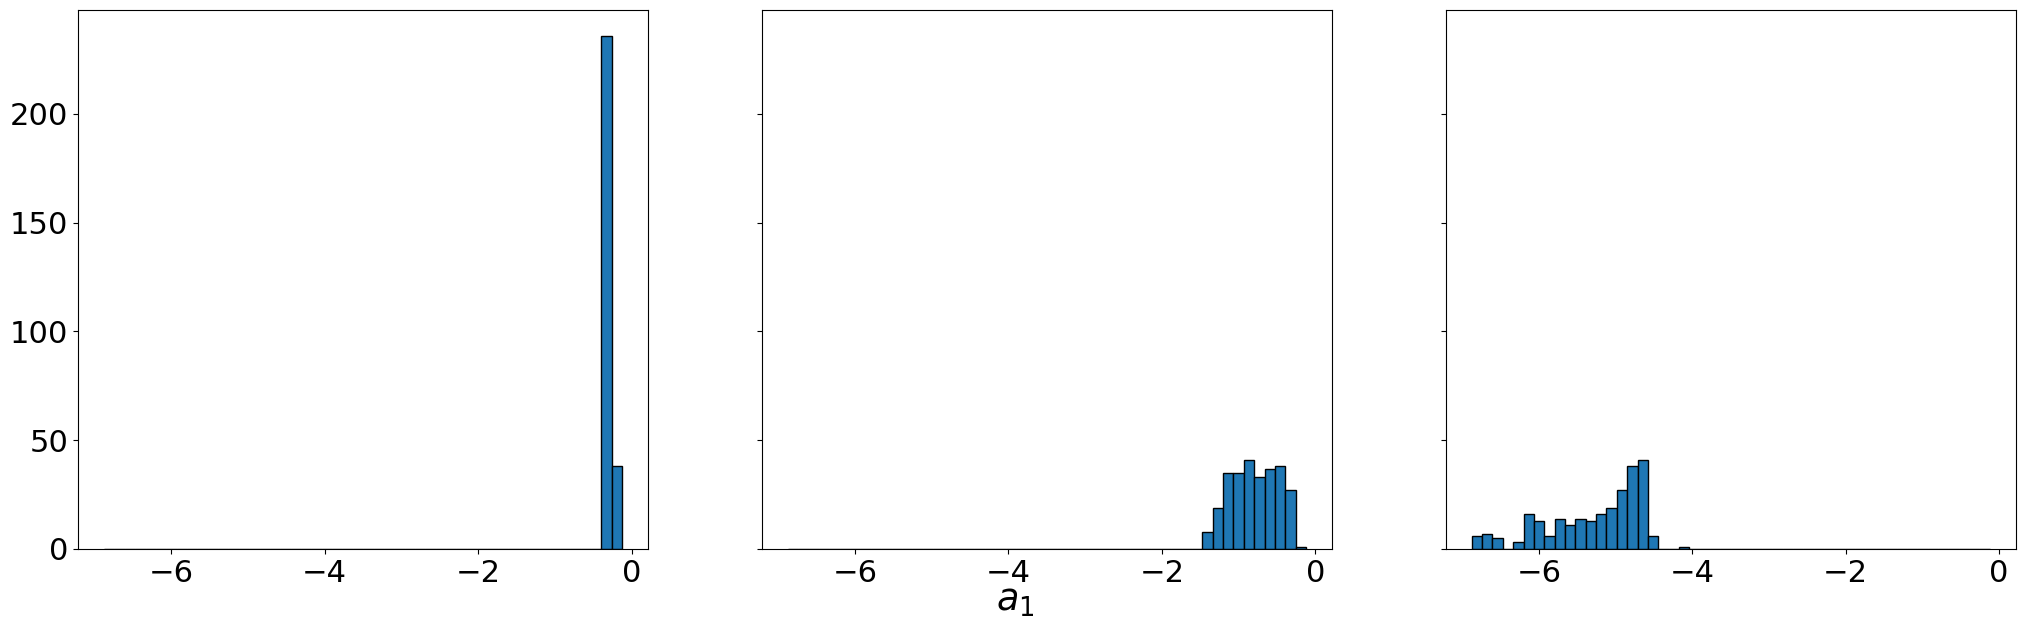

In [96]:
fig, axes = plt.subplots(1,3, figsize=(25,7), sharey=True)
hist = axes[0].hist(resultscnav['canonical']['an_1_0'], edgecolor='k', range=range, bins=50 ) #.plot.hist(bins=100)
hist = axes[1].hist(resultscnav['projections']['an_1_0'], edgecolor='k', range=range, bins=50 ) #.plot.hist(bins=100)
hist = axes[2].hist(resultscnav['projections_os']['an_1_0'], edgecolor='k', range=range, bins=50 ) #.plot.hist(bins=100)
fig.supxlabel(r'$a_1$', )
ax[0].set_ylabel('density counts')
fig.savefig(f'{dataset}/graphs/{dataset}_a1_distributions.eps')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


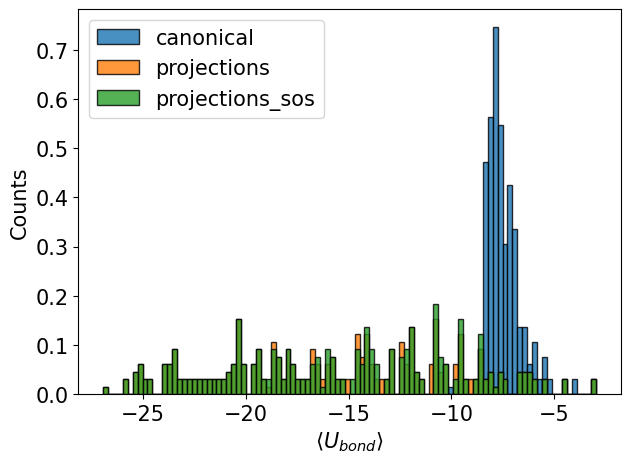

In [69]:
fig, axes = comparefeatures('U_bond_atom_list_1_0', 'U_{bond}', suffix='')
fig.savefig(f'{dataset}/graphs/{dataset}_Ubond_distributions.eps')

In [47]:
Ubond = {model: result['U_bond_atom_list_1_0'] for model, result in resultscnav.items()}

In [48]:
outliers = {'Ubond': {model: ubond[ubond < -50] for model, ubond in Ubond.items()} }

In [49]:
remove_ubond_outliers = [resultscnav[model].drop(index=ubondoutliers.index, inplace=True) for model, ubondoutliers in outliers['Ubond'].items()]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


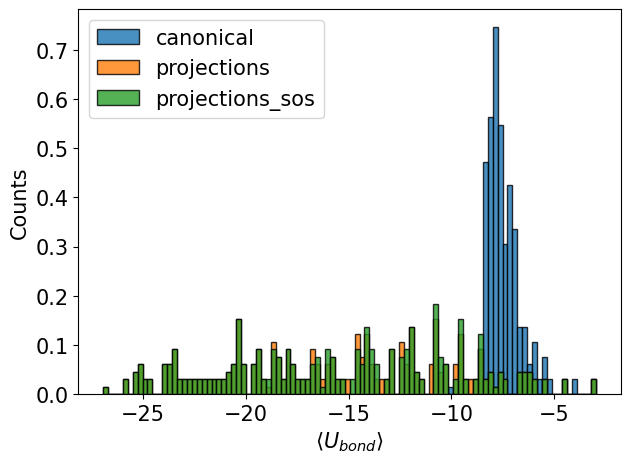

In [40]:
fig, axes = comparefeatures('U_bond_atom_list_1_0', 'U_{bond}', suffix='')
fig.savefig(f'{dataset}/graphs/Ubond_distribution.pdf')
fig.savefig(f'{dataset}/graphs/{dataset}_Ubond_distributions.eps')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


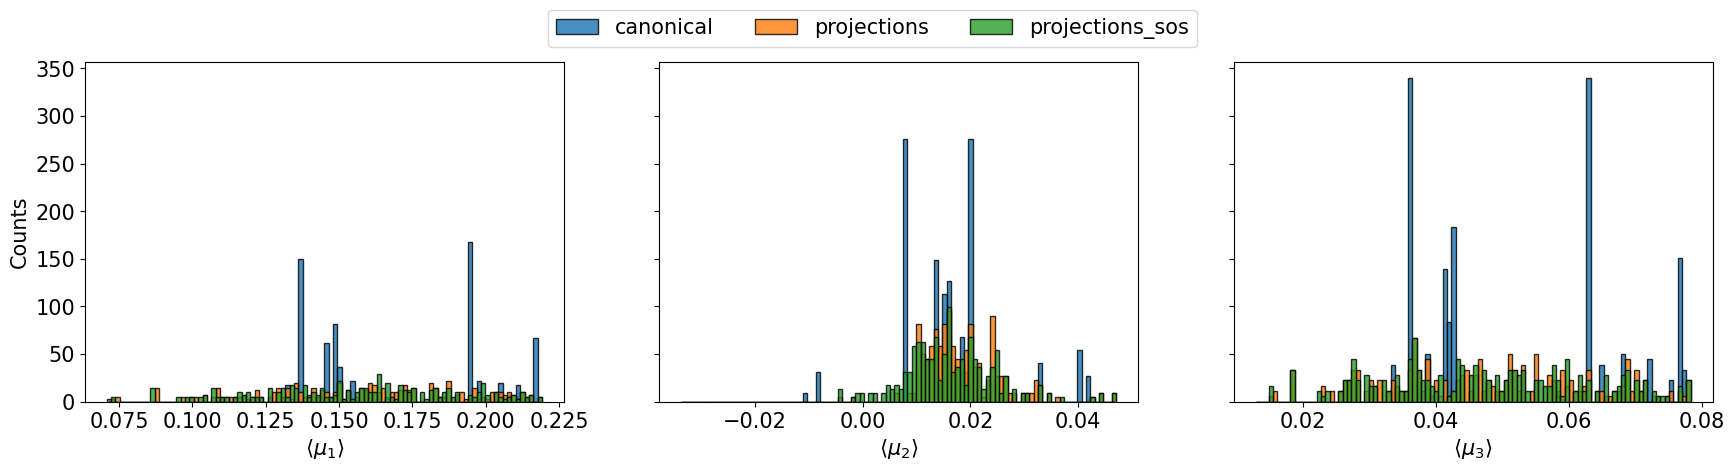

In [41]:
fig, axes = compare_many_orders('normed_moments','\mu')
fig.savefig(f'{dataset}/graphs/{dataset}_distributions_of_moments.eps', bbox_to_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


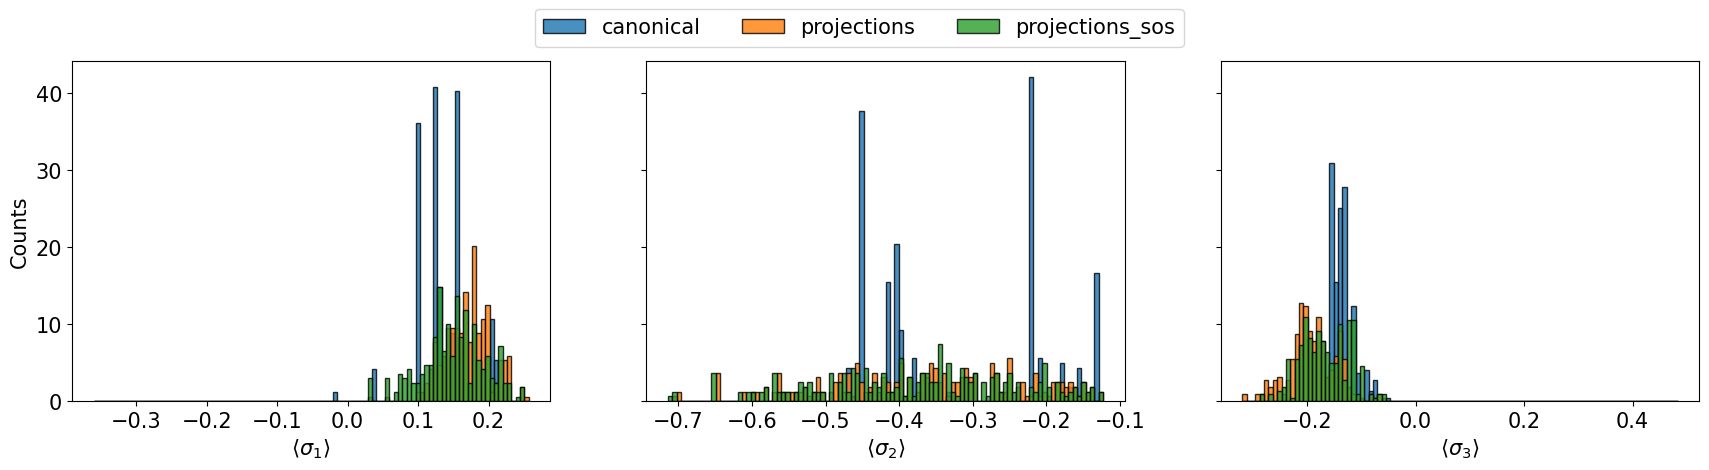

In [42]:
fig, ax = compare_many_orders('sigma', '\sigma')
fig.savefig(f'{dataset}/graphs/{dataset}_distributions_of_sigma.eps')


In [43]:
sigma1 = {model: result['sigma_1_0'] for model, result in resultscnav.items()}

In [44]:
outliers.update({'sigma1': {model: sigma[sigma < -0.50] for model, sigma in sigma1.items()}})

NameError: name 'outliers' is not defined

In [45]:
outliers['sigma1']

NameError: name 'outliers' is not defined

In [46]:
remove_sigma_outliers = [resultscnav[model].drop(index=sigmaoutliers.index, inplace=True) for model, sigmaoutliers in outliers['sigma1'].items()]

NameError: name 'outliers' is not defined

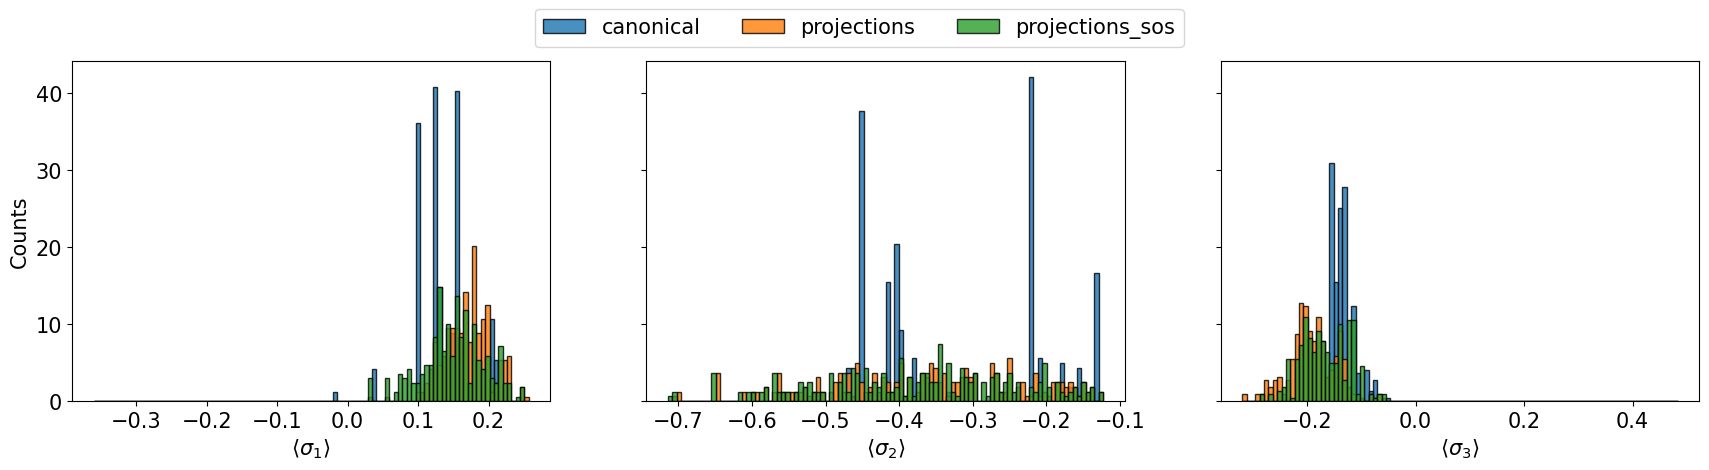

In [47]:
fig, ax  = compare_many_orders('sigma', r'\sigma')
fig.savefig(f'{dataset}/graphs/distribution_of_sigmas.pdf')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


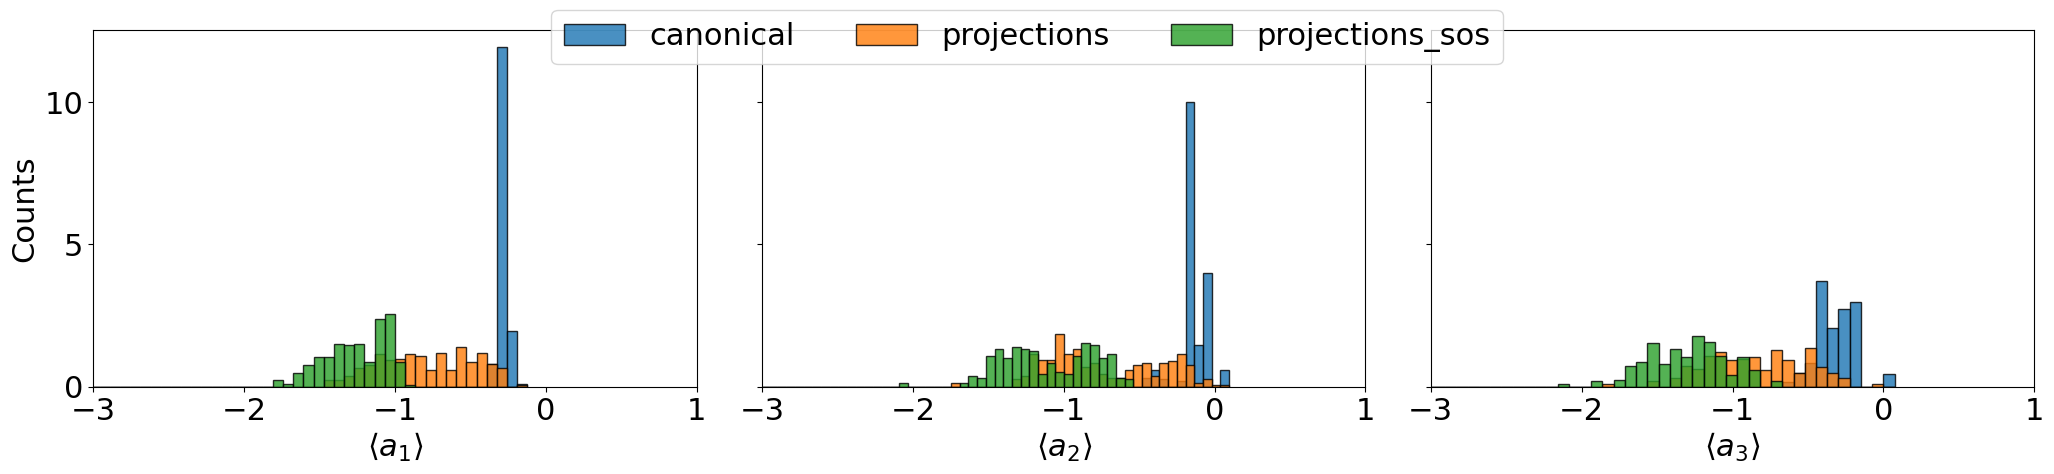

In [91]:
fig, ax  = compare_many_orders('an', 'a')
[tax.set_xlim([-3,1]) for tax in ax]
fig.tight_layout()
fig.savefig(f'{dataset}/graphs/{dataset}_distribution_an.eps', bbox_to_inches='tight')

In [49]:
an1 = {model: result['an_1_0'] for model, result in resultscnav.items()}

In [50]:
outliers.update({'an_1': {'canonical': an1['canonical'][an1['canonical'] > -0.2] }})

NameError: name 'outliers' is not defined

In [51]:
remove_sigma_outliers = [resultscnav[model].drop(index=sigmaoutliers.index, inplace=True) for model, sigmaoutliers in outliers['an_1'].items()]

NameError: name 'outliers' is not defined

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


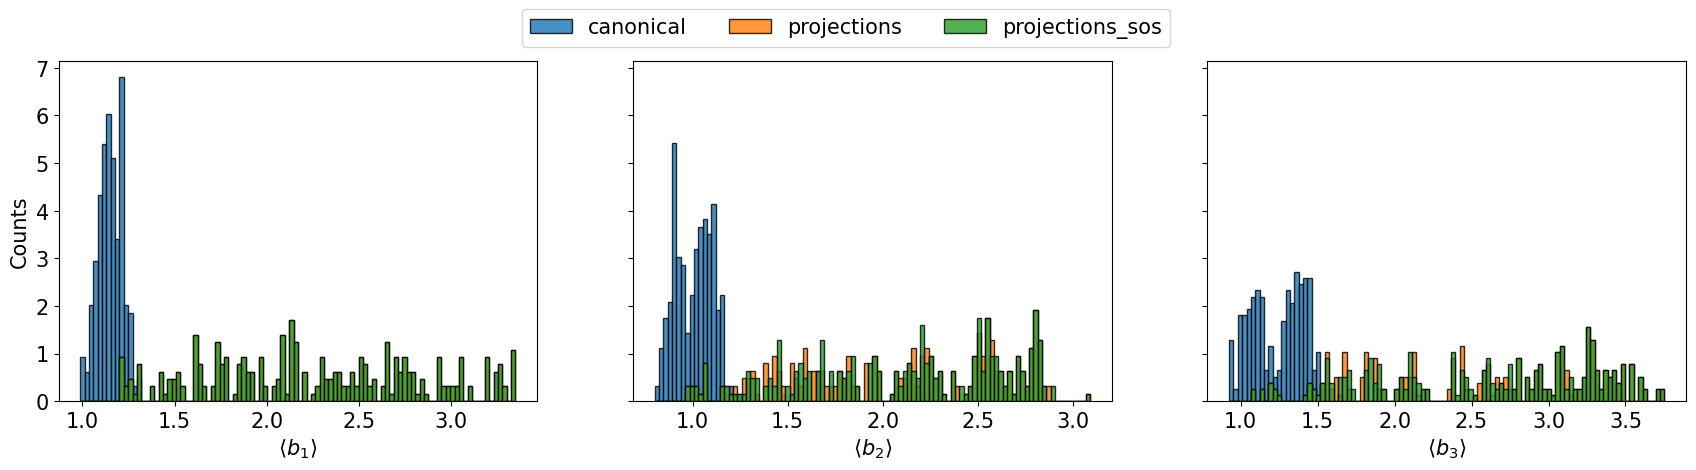

In [52]:
fig, ax = compare_many_orders('bn', 'b')
fig.savefig(f'{dataset}/graphs/{dataset}_distributions_bn.eps')

In [63]:
CP = ['0', 'CN12', 'CN13', 'CN14','CN15','CN16']
CPSYMB=['_{0}',  '{CN_{12}}', '{CN_{13}}', '{CN_{14}}','{CN_{15}}','{CN_{16}}']

In [64]:
featurename = 'normed_moments'
featuresymbol = '\mu'
model = 'canonical'
def compare_cns(featurename, featuresymbol, model, ax = None):
    if ax is None:
        fig, ax = plt.subplots()
    featuretitle = fr'$\langle {featuresymbol} \rangle$'
    for case, symbol in zip(CP,CPSYMB):
        featuremain = fr'{featurename}' 
        featurecol = fr'{featuremain}_{case}'
        ax.set_xlabel(featuretitle)
        thismin = resultscnav[model].filter(regex=featuremain).min().min()
        thismaxn = resultscnav[model].filter(regex=featuremain).max().max()
    #     = fr'${featuresymbol}_{i} $' for i in range(1,4)}
        ax.hist(resultscnav[model][f'{featurecol}'], label=f'${symbol}$',bins=100, edgecolor='k', alpha=0.7, range=[thismin, thismaxn])
    ax.legend()
    ax.set_ylabel('counts')
    ax.set_xlabel(featuretitle)
    return ax

In [65]:
def compare_cns_manyorders(featurename, featuresymbol, model):
    fig, ax = plt.subplots(1,3, figsize = (21,5), sharey=True)
    for i, tax in enumerate(ax):
        featuremain = fr'{featurename}_{i+1}'
        featuretitle = fr'{featuresymbol}_{i+1}'
        tax = compare_cns(featuremain, featuretitle, model, ax = tax)
        tax.legend().remove()
    handles, labels = ax[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 1.1))
    ax[0].set_ylabel('counts')
    ax[0].set_ylim([0, 500])

(-15.0, 5.0)

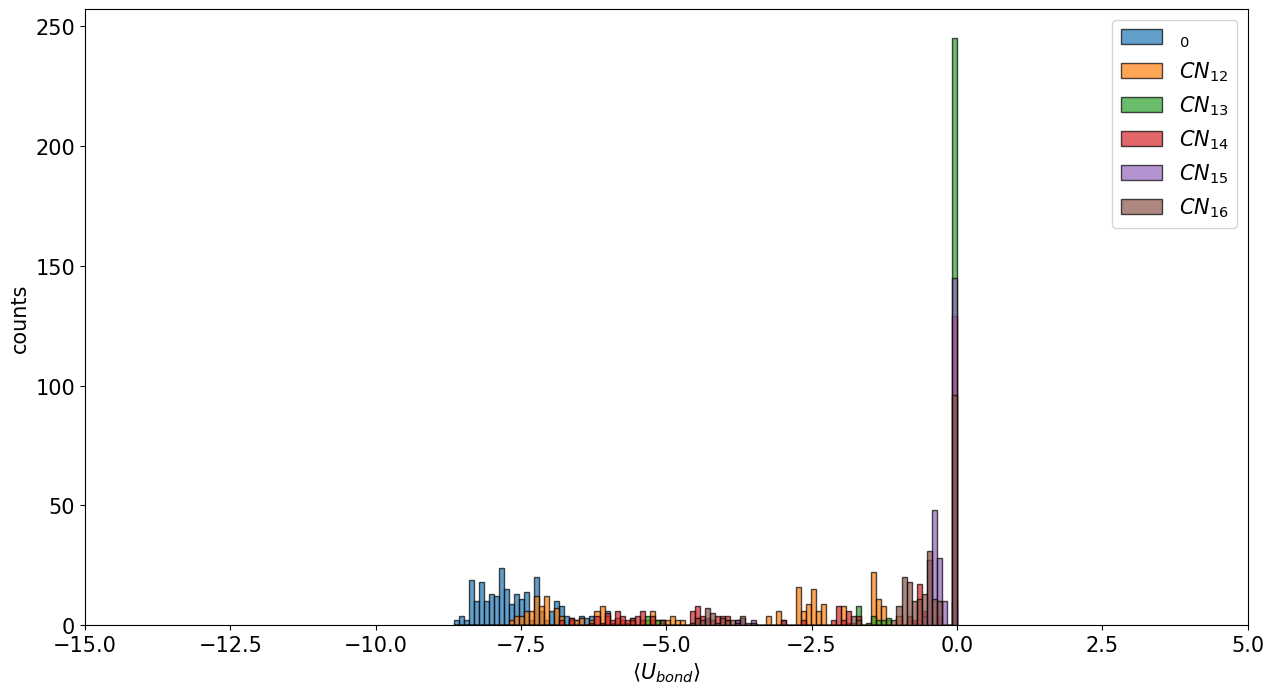

In [66]:
ax = compare_cns('U_bond_atom_list_1', 'U_{bond}', 'canonical')
ax.set_xlim([-15, 5])

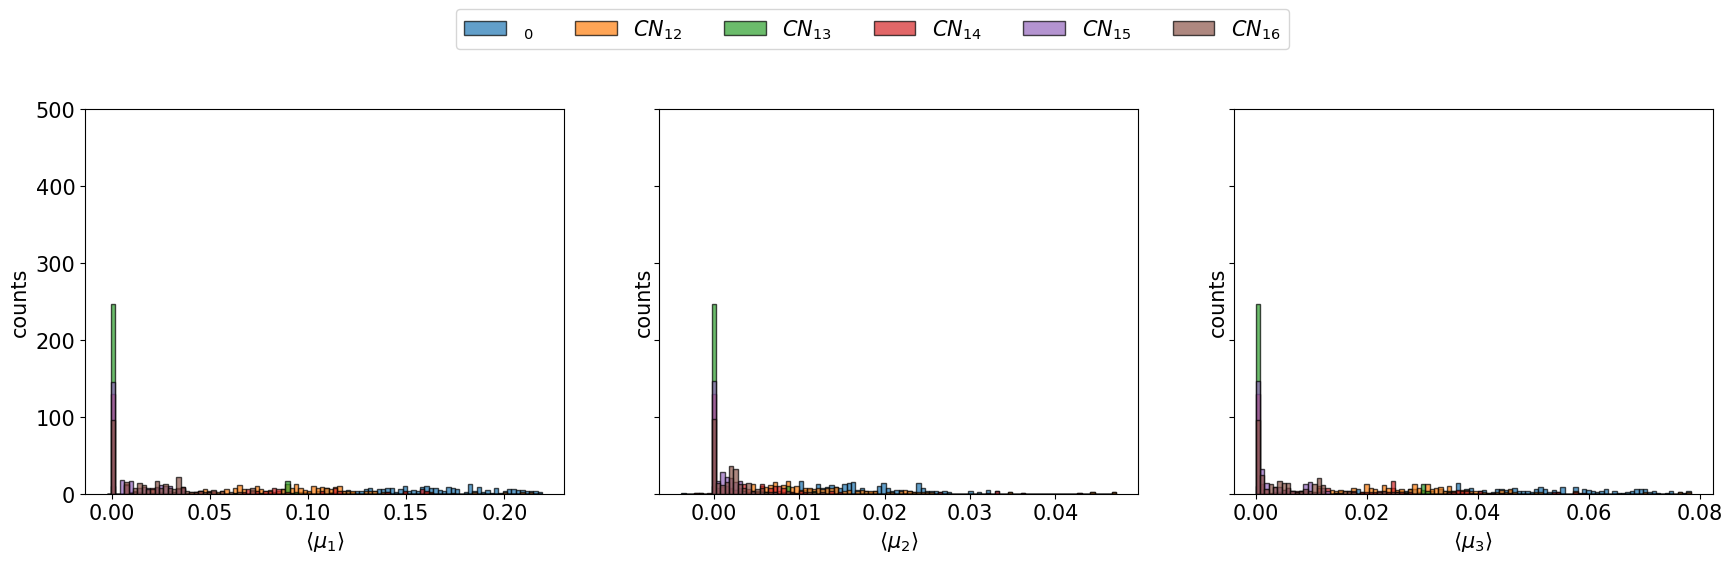

In [67]:
compare_cns_manyorders('normed_moments', '\mu', 'projections')

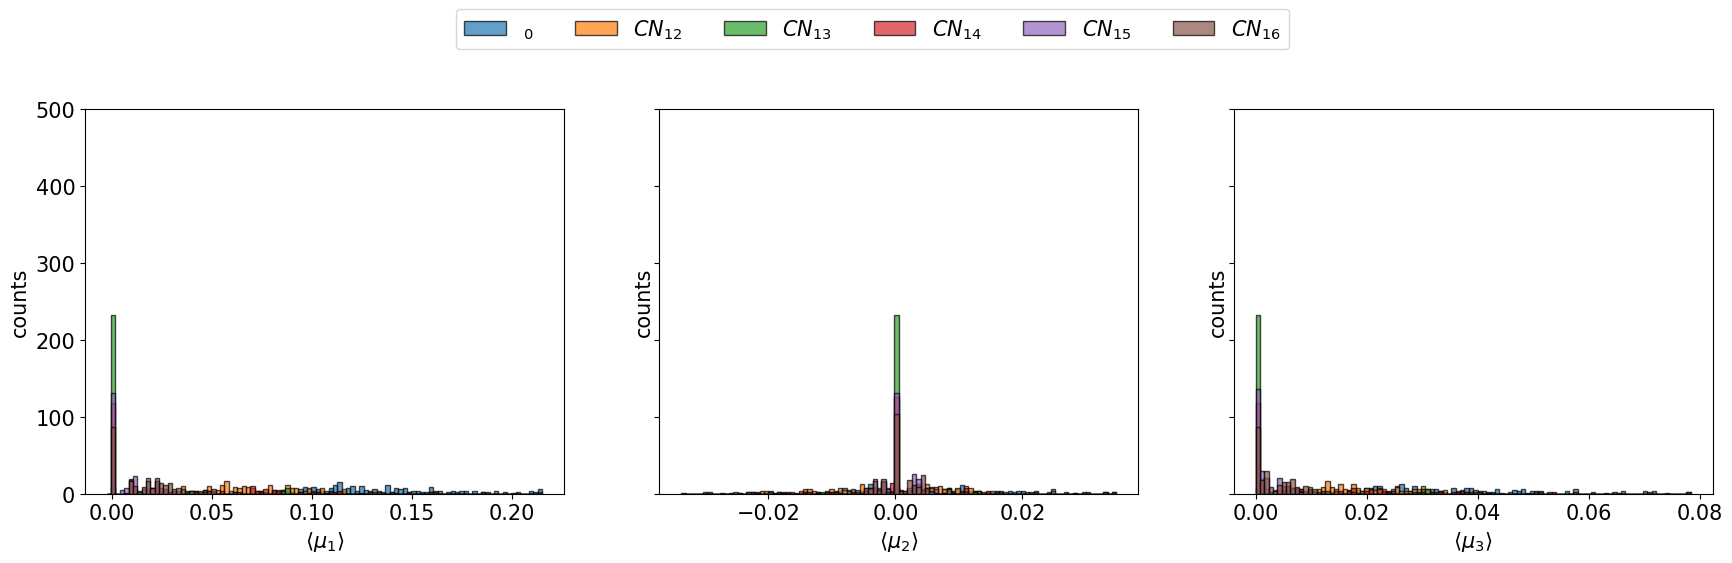

In [68]:
compare_cns_manyorders('normed_moments', '\mu', 'projections_os')

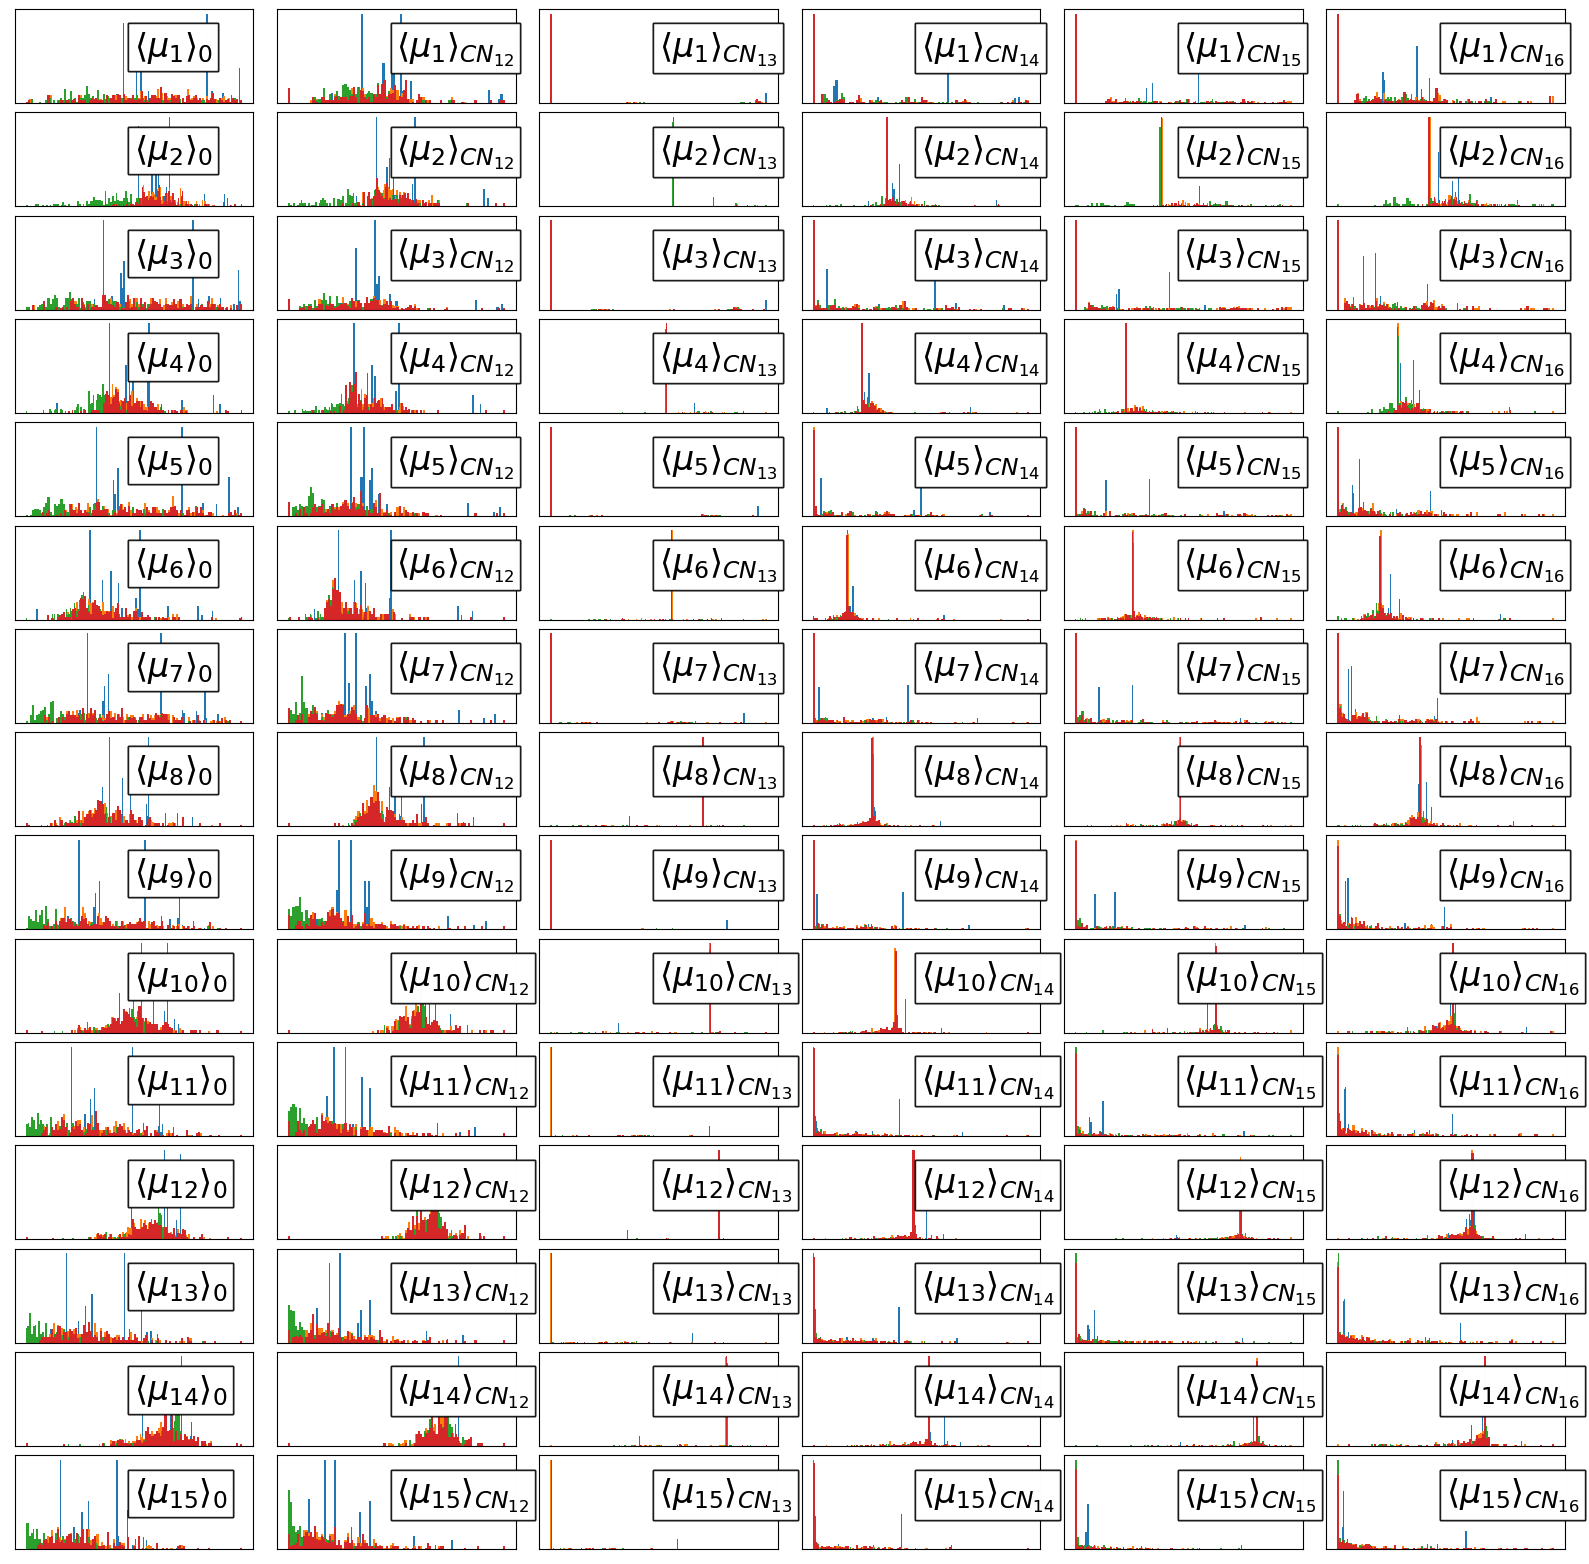

In [69]:
import Tools.DatasetTools.Tools as tl
plotter = tl.Plotting
selection = resultscnav['canonical'].columns.str.contains('normed_moments')
normedmomentnames = resultscnav['canonical'].columns[selection]
normedmomenttitles = pd.Series({name: re.sub('normed_moments_(.*)_',r'$\\langle \\mu_{\1} \\rangle ', name)+'$' for name in normedmomentnames})
normedmomenttitles = normedmomenttitles.map(lambda s: re.sub(' 0\$','_{0}$', s))
normedmomenttitles = normedmomenttitles.map(lambda s: re.sub(' CN(.*)\$','_{CN_{\\1}}$', s))
fig, ax = plotter.histoff_realfeatures(resultscnav['canonical'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6)
fig, ax = plotter.histoff_realfeatures(resultscnav['projections'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6, fig_ax=(fig, ax))
fig, ax = plotter.histoff_realfeatures(resultscnav['projections_os'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6, fig_ax=(fig, ax))
fig, ax = plotter.histoff_realfeatures(resultscnav['projections_sos'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6, fig_ax=(fig, ax))

## Shape factors 

In [70]:
resultscnav['canonical'].filter(regex='sf')

,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16
Fe_pv8Mo_sv22.sigma-BBABB.FM,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000
Fe_pv10Mo_sv20.sigma-ABBAB.FM,1.224174,1.311938,0.000000,1.187308,1.155463,0.000000
Fe_pv4Mo_sv20.C36-ABBBB.FM,1.081732,1.156282,0.000000,0.000000,0.000000,0.901327
Fe_pv5Mo_sv24.chi-AABB.FM,1.251703,1.437268,1.179083,0.000000,0.000000,1.006205
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,1.192249,1.343509,0.000000,1.139857,0.956735,0.947607
...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,1.071111,1.222567,0.000000,0.902499,0.748344,1.001884
Fe_pv8Mo_sv22.sigma-BBABB.NM,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000
Fe_pv1Mo_sv3.L12-AB3.FM,1.140024,1.140024,0.000000,0.000000,0.000000,0.000000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000


(<Figure size 700x500 with 1 Axes>,
 <AxesSubplot:xlabel='$\\langle b_1 / b_2 \\rangle $', ylabel='Counts'>)

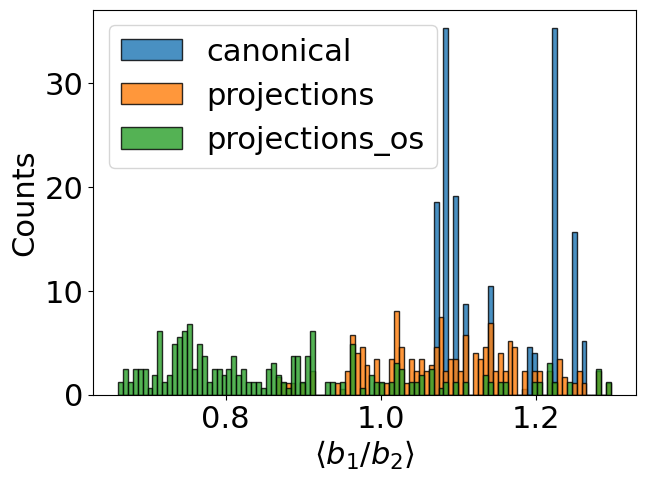

In [71]:
comparefeatures('sf', 'b_1 / b_2', )

# Correlations

In [72]:
BS = pd.read_pickle(f'{dataset}/FullyCuratedParsedBriefSummary.pkl')

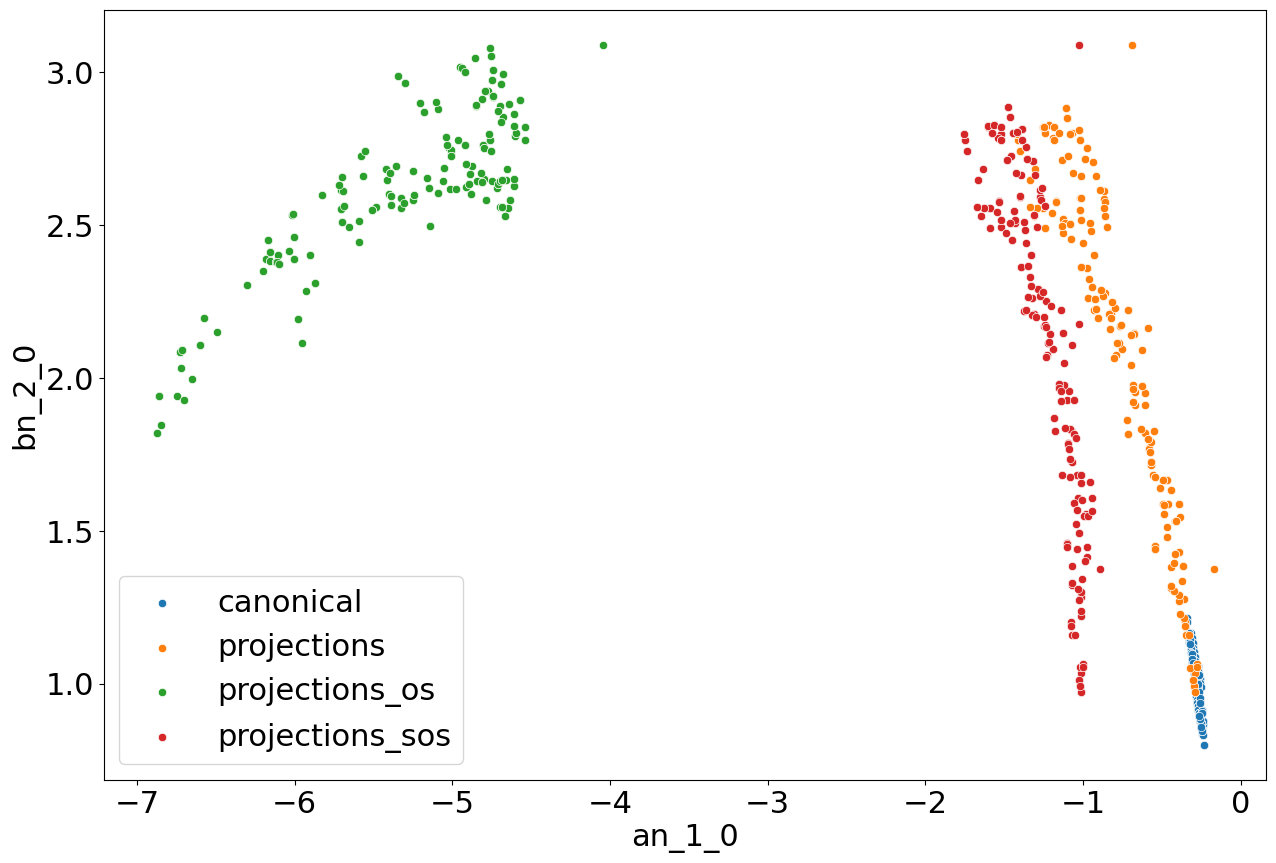

In [73]:
ax = sns.scatterplot(data = resultscnav['canonical'][resultscnav['canonical']['bn_2_0']<4], x = 'an_1_0', y ='bn_2_0')
ax = sns.scatterplot(data = resultscnav['projections'][resultscnav['projections']['bn_2_0']<6], x = 'an_1_0', y ='bn_2_0', ax = ax)
ax = sns.scatterplot(data = resultscnav['projections_os'][resultscnav['projections_os']['bn_2_0']<6], x = 'an_1_0', y ='bn_2_0', ax = ax)
ax = sns.scatterplot(data = resultscnav['projections_sos'][resultscnav['projections_sos']['bn_2_0']<6], x = 'an_1_0', y ='bn_2_0', ax = ax)
ax.legend(['canonical', 'projections', 'projections_os', 'projections_sos'])

##  shape-factors

In [74]:
BS.index.difference(resultscnav['canonical'].index)

Index(['Fe_pv53.R.NM', 'Mo_sv53.R.NM'], dtype='object')

In [75]:
resultscnav['canonical'].index.difference(BS.index)

Index(['Mo_sv56.delta.NM'], dtype='object')

In [76]:
models

['canonical', 'projections', 'projections_os', 'projections_sos']

In [77]:
import pdb

In [78]:
def target_correlation_scatters (featurename, featuresymbol, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    selection={model: BS.index.intersection(result[featurename].index) for model, result in resultscnav.items()}
    [sns.scatterplot(x=resultscnav[model][featurename].loc[selection[model]], y = BS['EF'][selection[model]], ax = ax) for model in models]
    ax.set_ylabel('$\Delta E_f$')
    ax.set_xlabel(featuresymbol)
    ax.legend(models)
    return ax

In [79]:
def correlation_vs_order(feature, featuresymbol, order=[1,2,3,4]):
    fig, axes = plt.subplots(1, len(order),  sharey=True, figsize=(7*4, 5))
    for i, ax in enumerate(axes):
        thisfeaturename = f'{feature}_{order[i]}_0'
        thisfeaturesymbol = f'${featuresymbol}_{order[i]}$'
        ax = target_correlation_scatters(thisfeaturename, thisfeaturesymbol, ax=ax)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, ncol=len(labels), loc='upper center')

##  The Ubond spread is too big

that might be because the bond integrals are too strong, due to the fact that they are caclulated from dimers, which are not screened. In this close packed structures the interaction is maybe screened by neighbours so the actual interactin is weacker

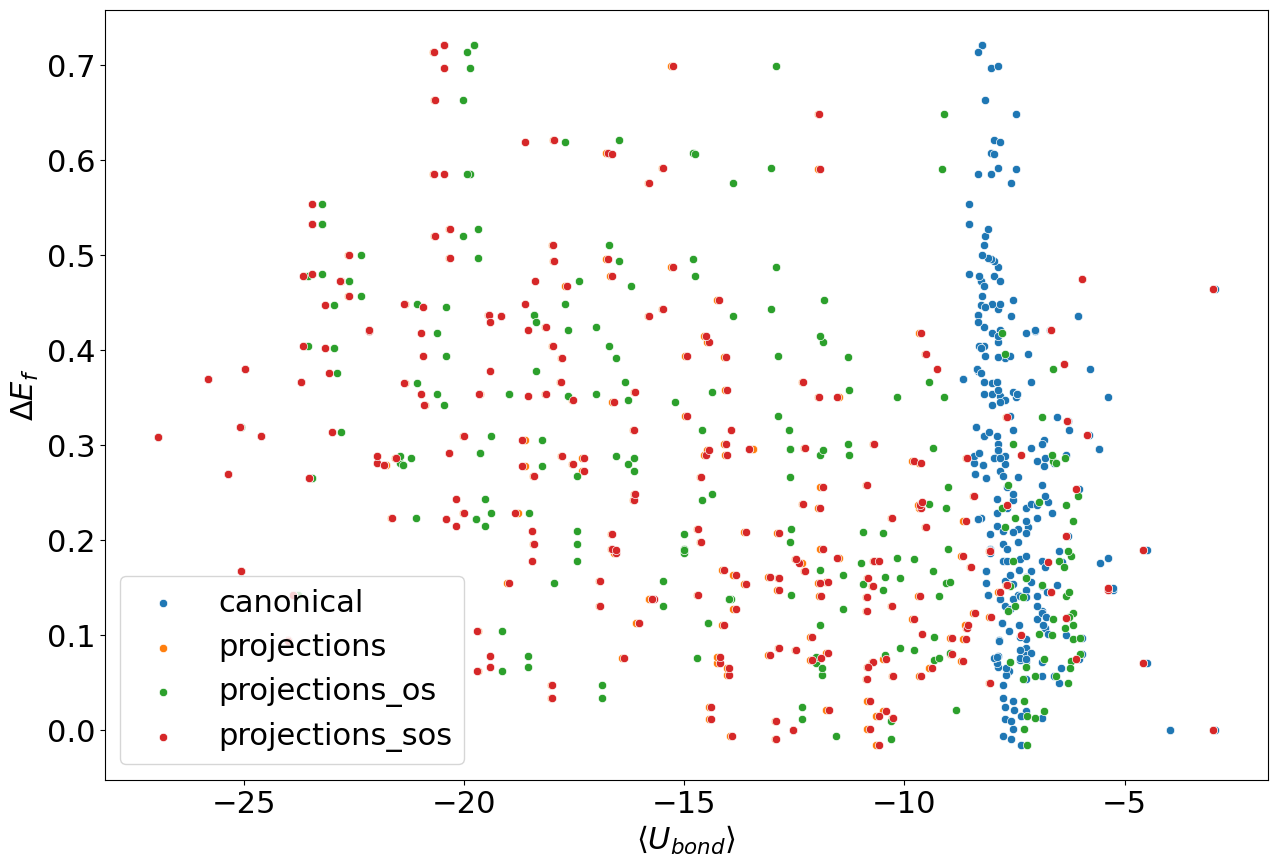

In [80]:
ax = target_correlation_scatters('U_bond_atom_list_1_0', r'$\langle U_{bond} \rangle$')
#ax.set_xlim([-50, 0])resultscnav

In [30]:
correlation_vs_order('an', 'a', order=[1,2,3])

NameError: name 'correlation_vs_order' is not defined

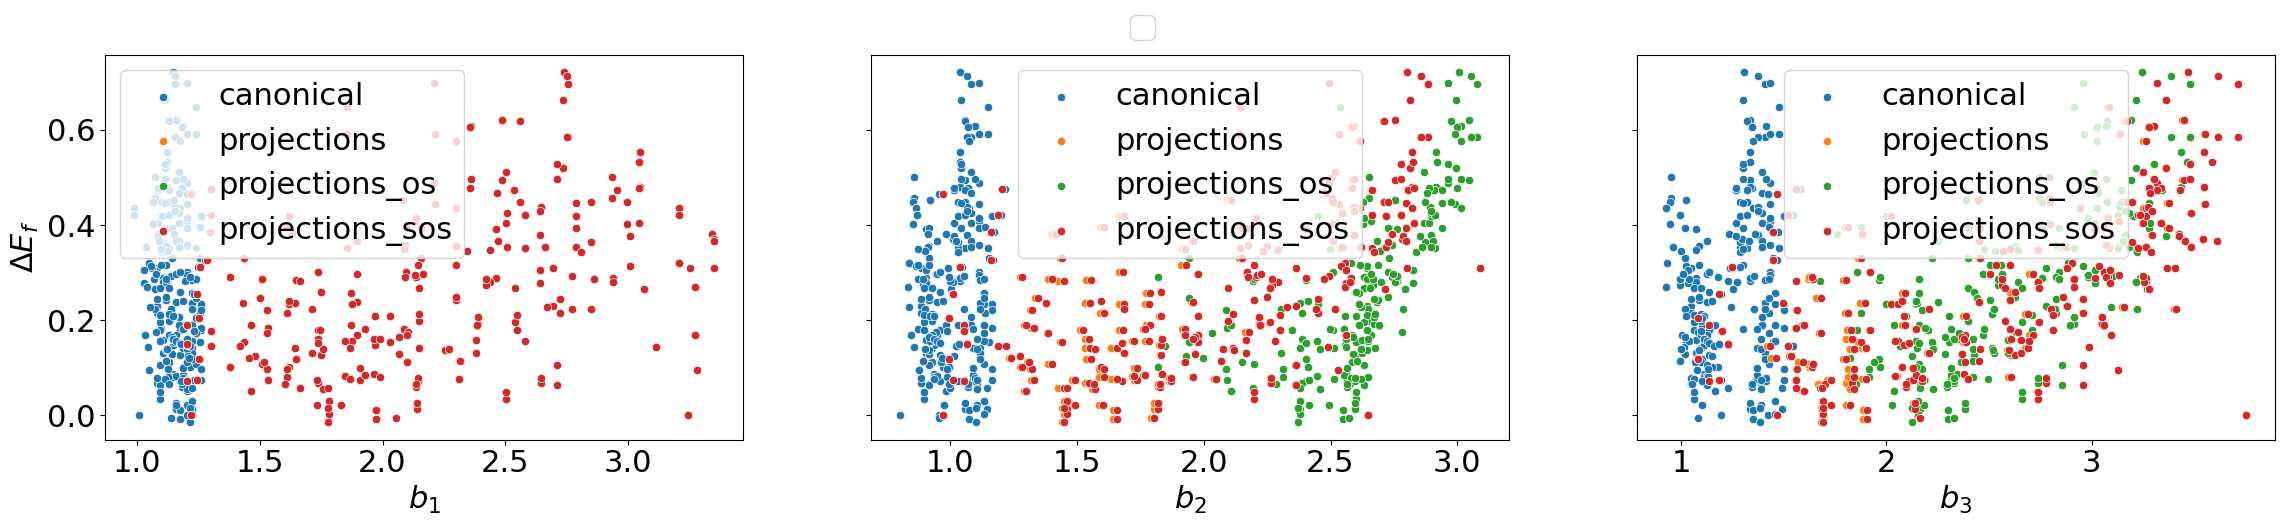

In [52]:
correlation_vs_order('bn', 'b', order=[1,2,3])

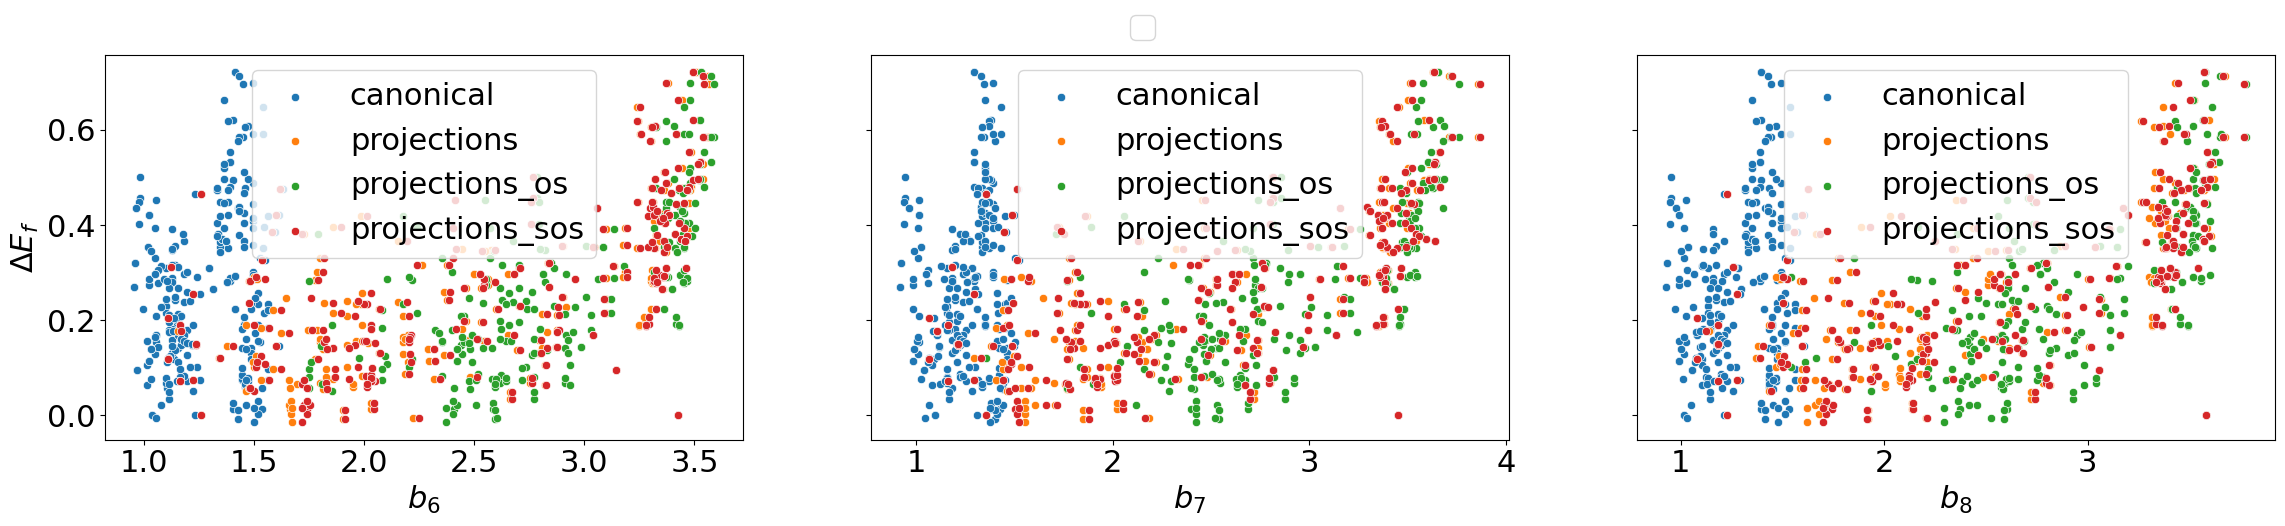

In [53]:
correlation_vs_order('bn', 'b', order=[6,7,8])

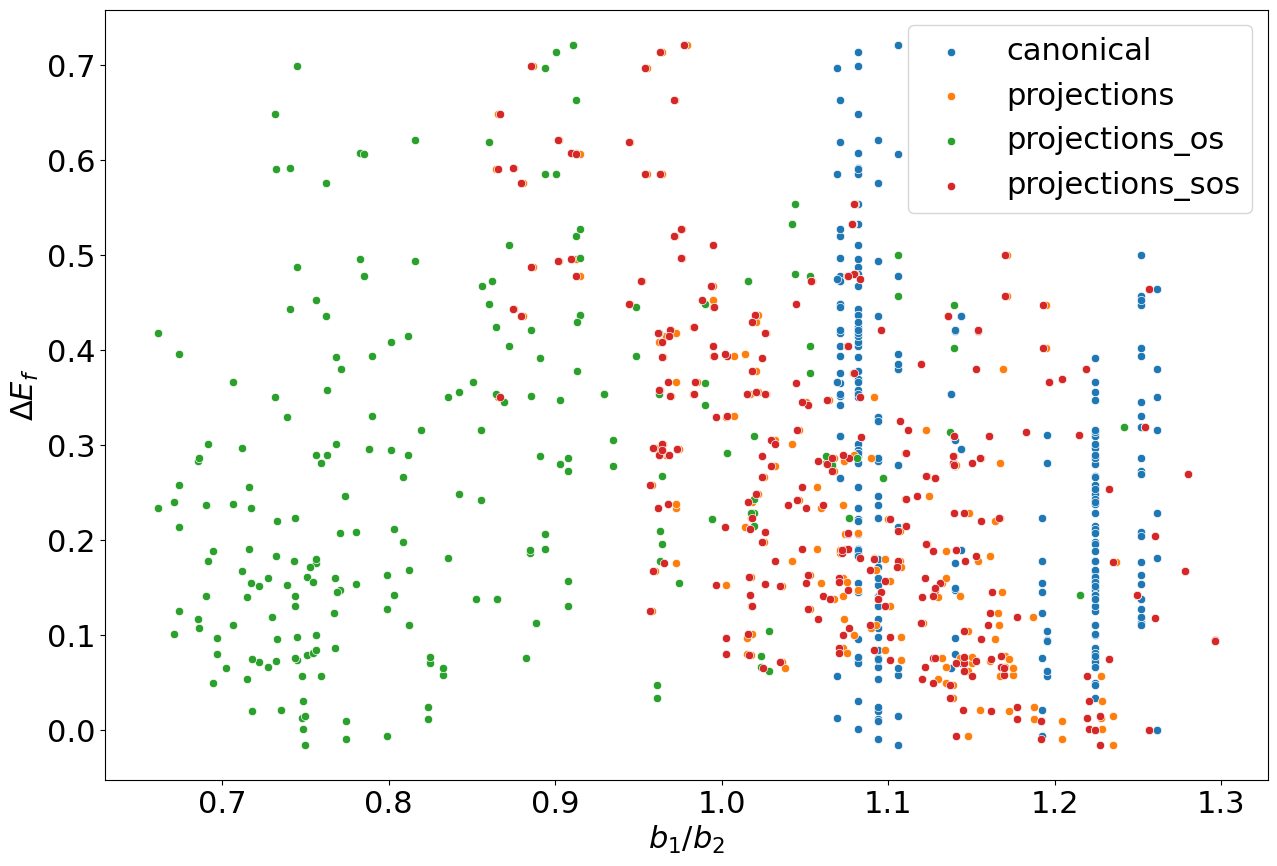

In [54]:
ax = target_correlation_scatters('sf_0', '$b_1 / b_2$')

<AxesSubplot:xlabel='$U_{bind}$', ylabel='$\\Delta E_f$'>

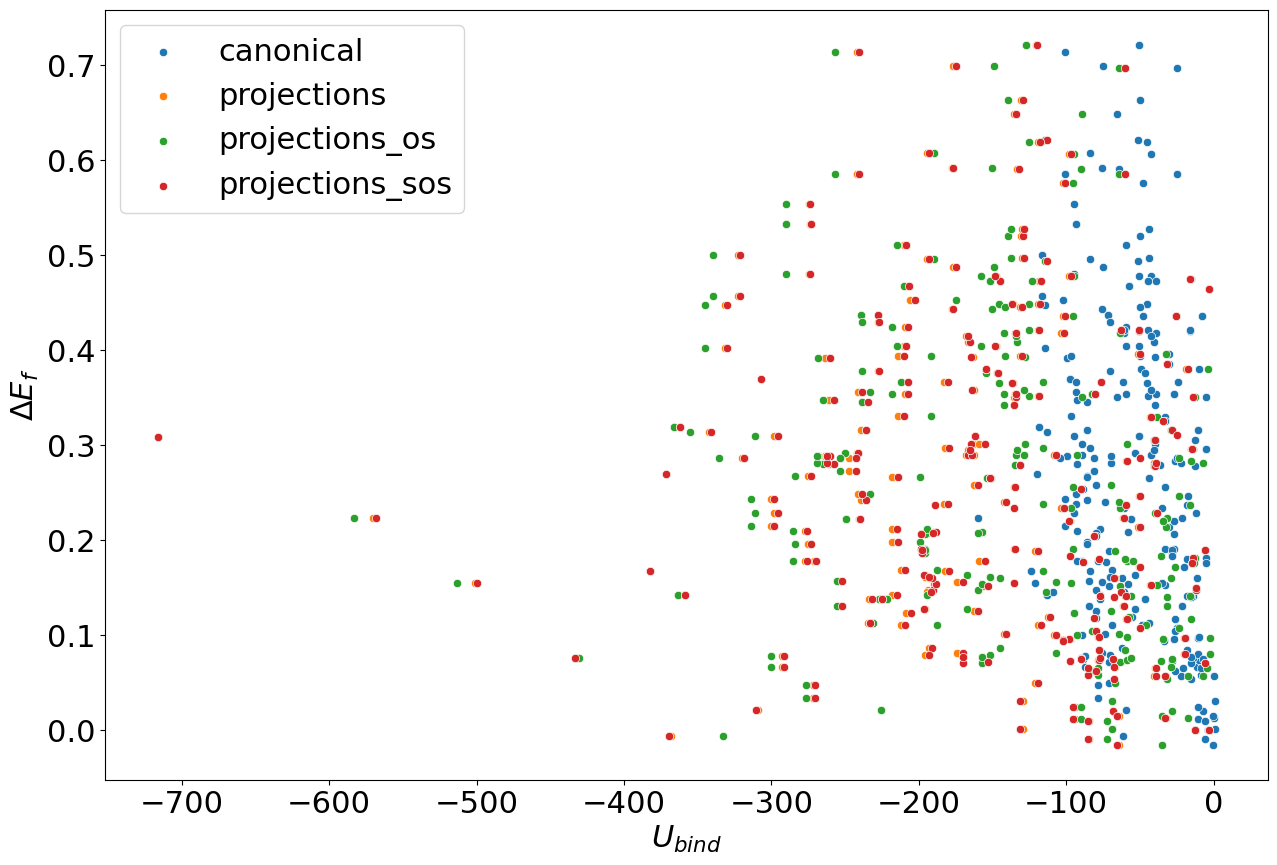

In [55]:
target_correlation_scatters('U_bind', '$U_{bind}$')

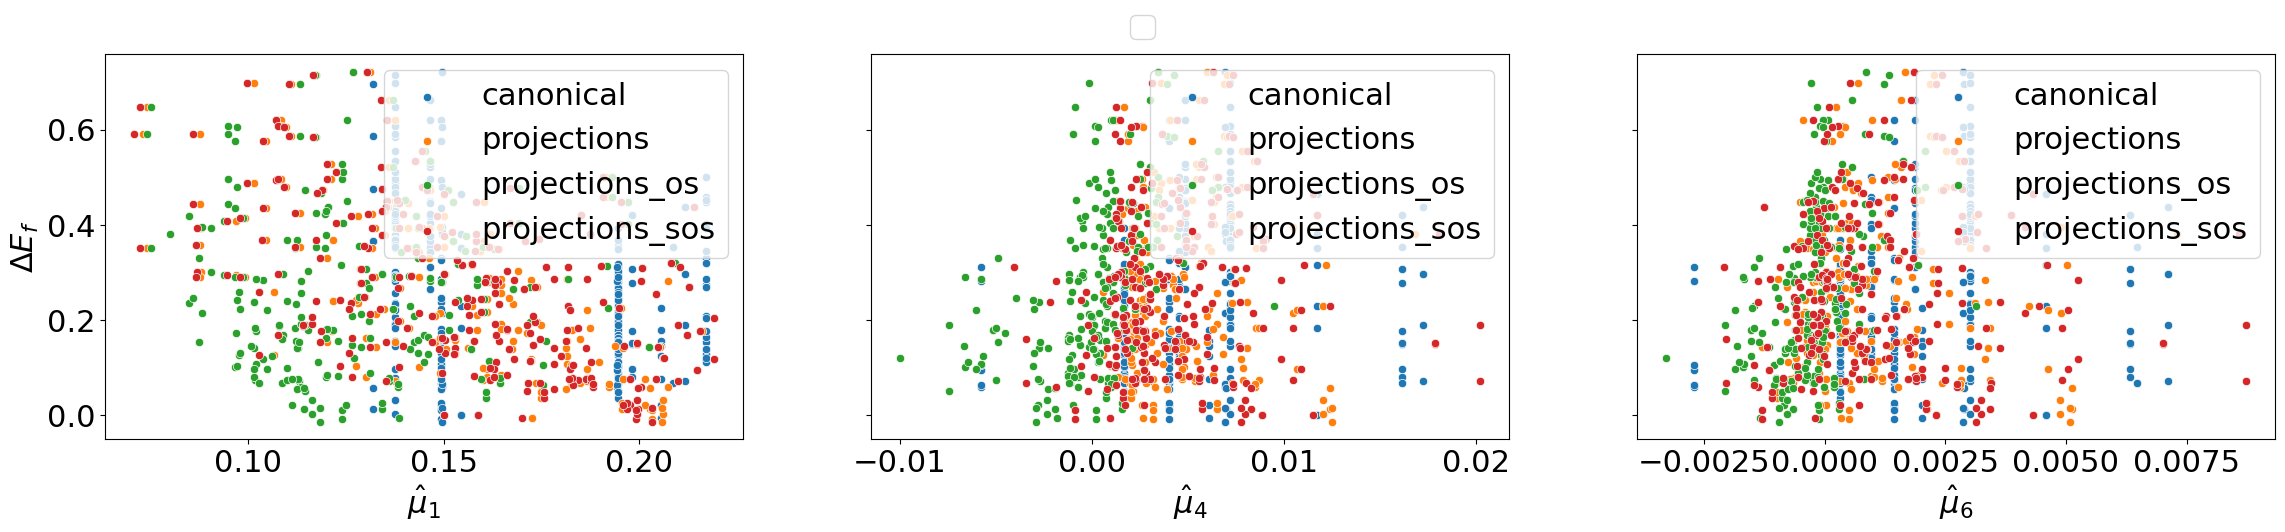

In [56]:
correlation_vs_order('normed_moments', '\hat{\mu}', order=[1,4,6])

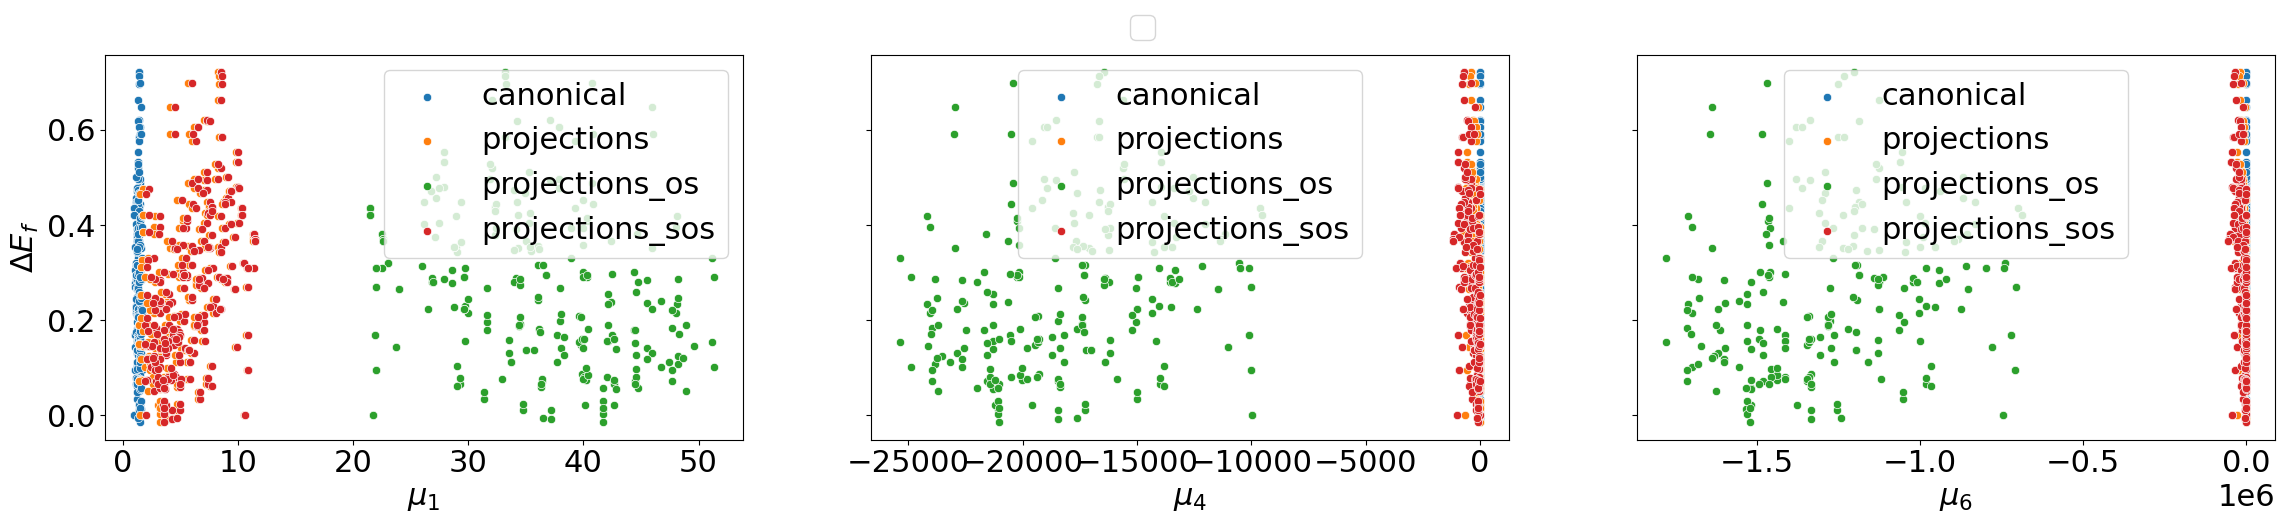

In [57]:
correlation_vs_order('moments', '\mu', order=[1,4,6])

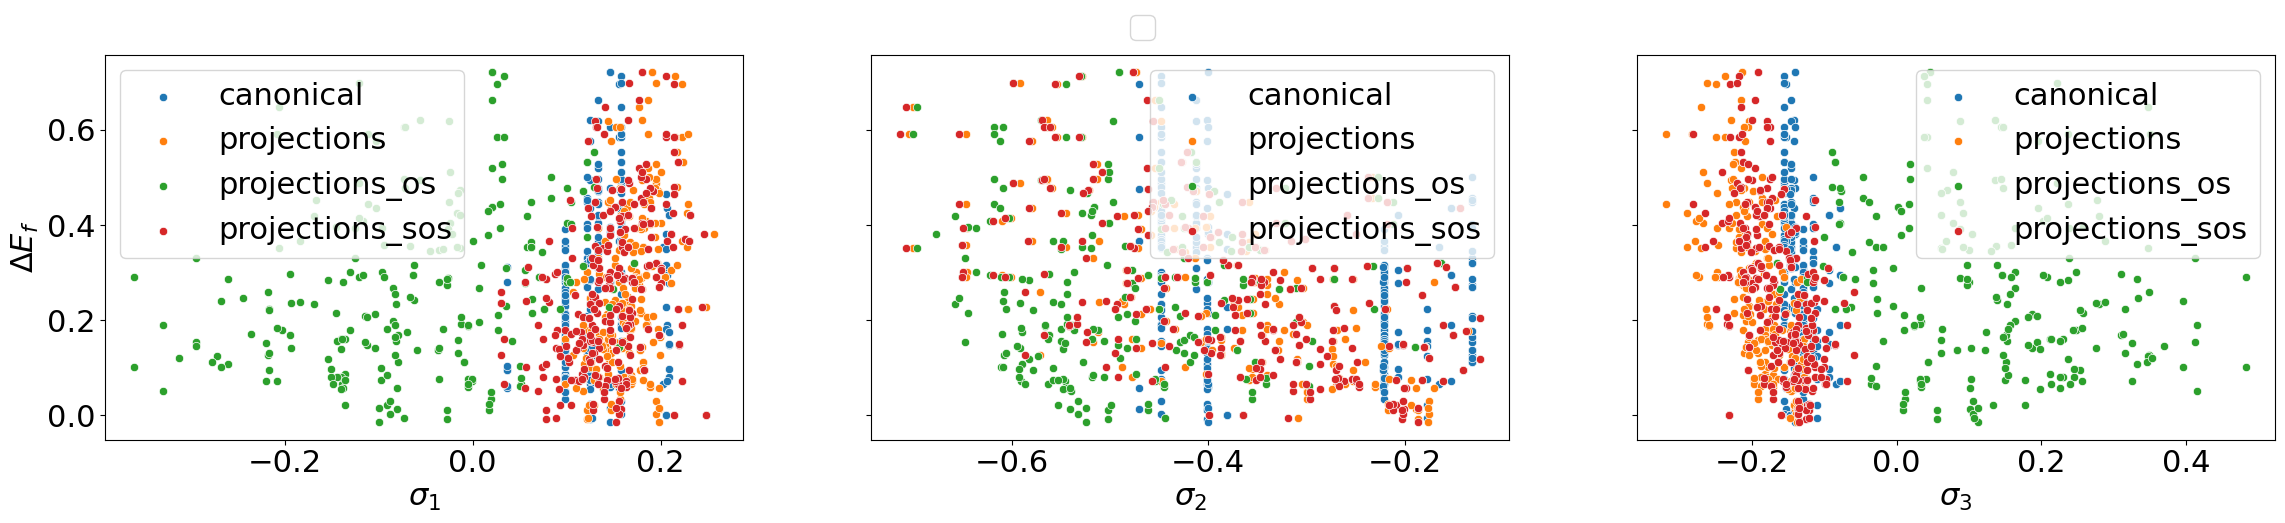

In [58]:
correlation_vs_order('sigma', '\sigma', order=[1,2,3])

# Compute pearson correlations explicitly 

In [59]:
model = 'canonical'

In [60]:
BS['EF'] = BS['EF'].astype(float)

In [61]:
TargetCorrelations =  {}

In [62]:
resultscnav['canonical'].astype(float) #['U_bind'].astype(float).corr(BS['E0'])

,U_bind,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,moments_1_CN12,moments_1_CN13,...,Binf_1_CN13,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16
Fe_pv8Mo_sv22.sigma-BBABB.FM,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,0.433709,0.000000,...,0.000000,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000
Fe_pv10Mo_sv20.sigma-ABBAB.FM,-78.594335,-7.771059,-1.424594,0.000000,-5.906606,-0.439859,0.000000,1.201761,0.443751,0.000000,...,0.000000,0.668575,0.166260,0.000000,1.224174,1.311938,0.000000,1.187308,1.155463,0.000000
Fe_pv4Mo_sv20.C36-ABBBB.FM,-94.449166,-8.534487,-7.595698,0.000000,0.000000,0.000000,-0.938789,1.303069,1.079142,0.000000,...,0.000000,0.000000,0.000000,0.501537,1.081732,1.156282,0.000000,0.000000,0.000000,0.901327
Fe_pv5Mo_sv24.chi-AABB.FM,-116.205661,-8.244366,-6.070495,-1.652565,0.000000,0.000000,-0.521305,1.162619,0.589668,0.434727,...,0.451346,0.000000,0.000000,0.186186,1.251703,1.437268,1.179083,0.000000,0.000000,1.006205
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,-121.105805,-8.136275,-2.533063,0.000000,-0.844603,-0.318349,-4.440260,1.218738,0.765044,0.000000,...,0.000000,0.256809,0.124851,0.170809,1.192249,1.343509,0.000000,1.139857,0.956735,0.947607
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,-40.035290,-8.020136,-2.520056,0.000000,-0.663807,-0.397166,-4.439107,1.265062,0.918735,0.000000,...,0.000000,0.220371,0.224323,0.222761,1.071111,1.222567,0.000000,0.902499,0.748344,1.001884
Fe_pv8Mo_sv22.sigma-BBABB.NM,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,0.433709,0.000000,...,0.000000,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000
Fe_pv1Mo_sv3.L12-AB3.FM,-12.617373,-6.832601,-6.832601,0.000000,0.000000,0.000000,0.000000,1.063750,1.063750,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.140024,1.140024,0.000000,0.000000,0.000000,0.000000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,-94.569986,-7.892530,-5.305761,0.000000,-2.136368,-0.450401,0.000000,1.174563,0.433709,0.000000,...,0.000000,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000


In [63]:
for model in models :
    TargetCorrelations[model] = resultscnav[model].corrwith(BS['EF']).dropna().abs().sort_values(ascending=False)

In [64]:
models

['canonical', 'projections', 'projections_os', 'projections_sos']

Text(0, 0.5, 'Corr(x, $\\Delta E_f$)')

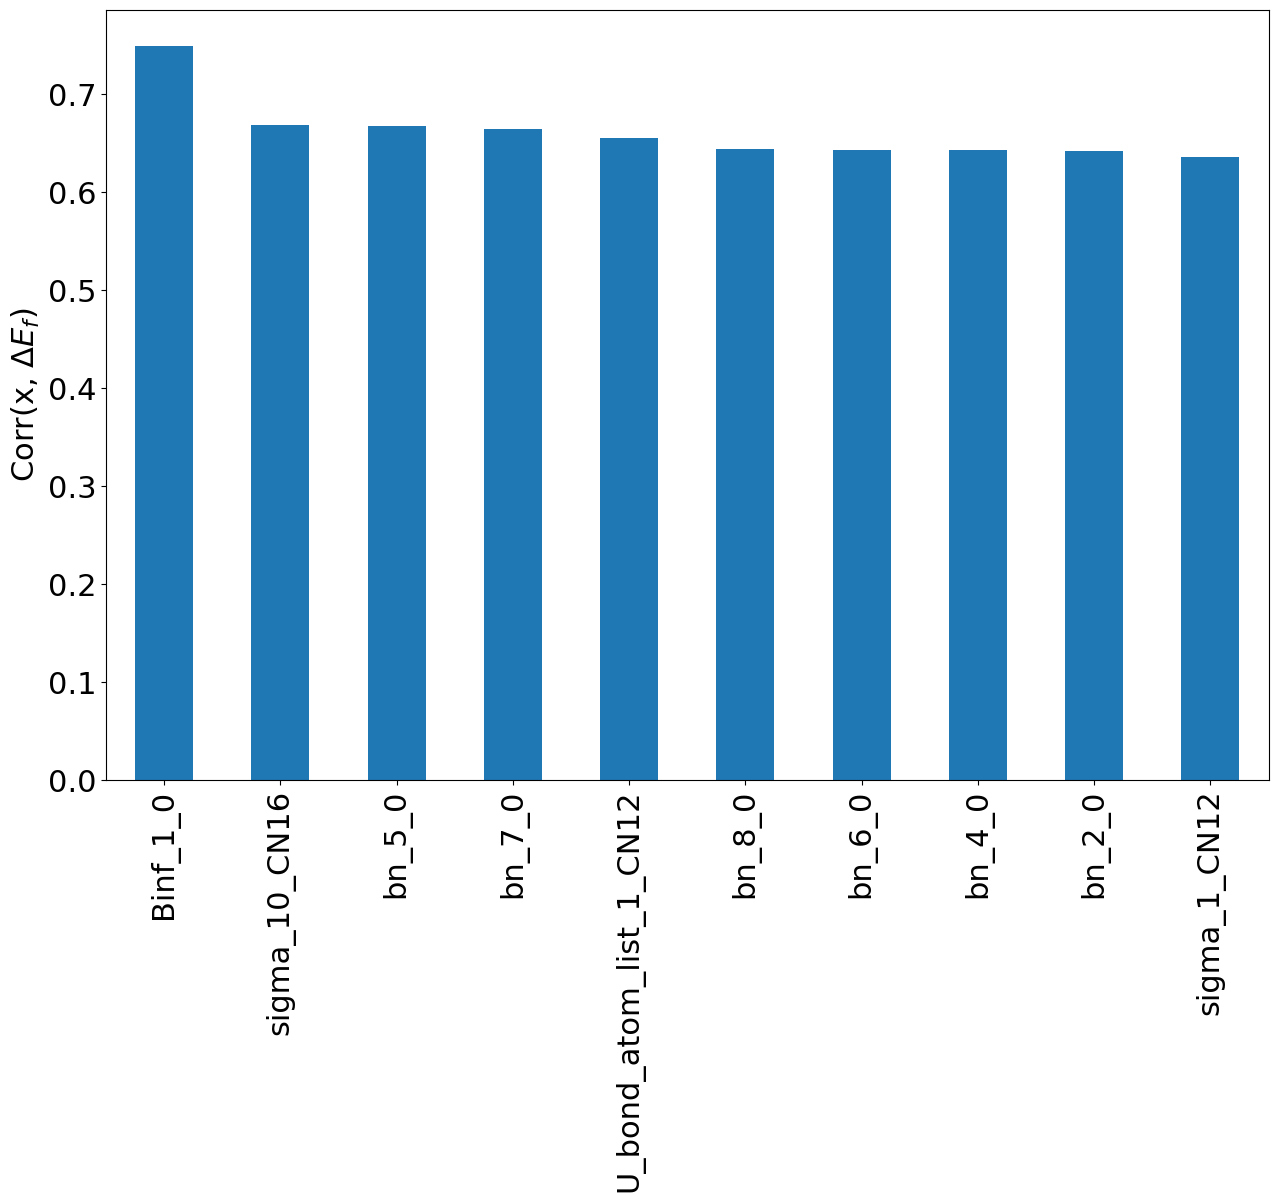

In [65]:
ax = TargetCorrelations['projections_os'][:10].plot(kind='bar')
ax.set_ylabel ('Corr(x, $\Delta E_f$)')

<AxesSubplot:>

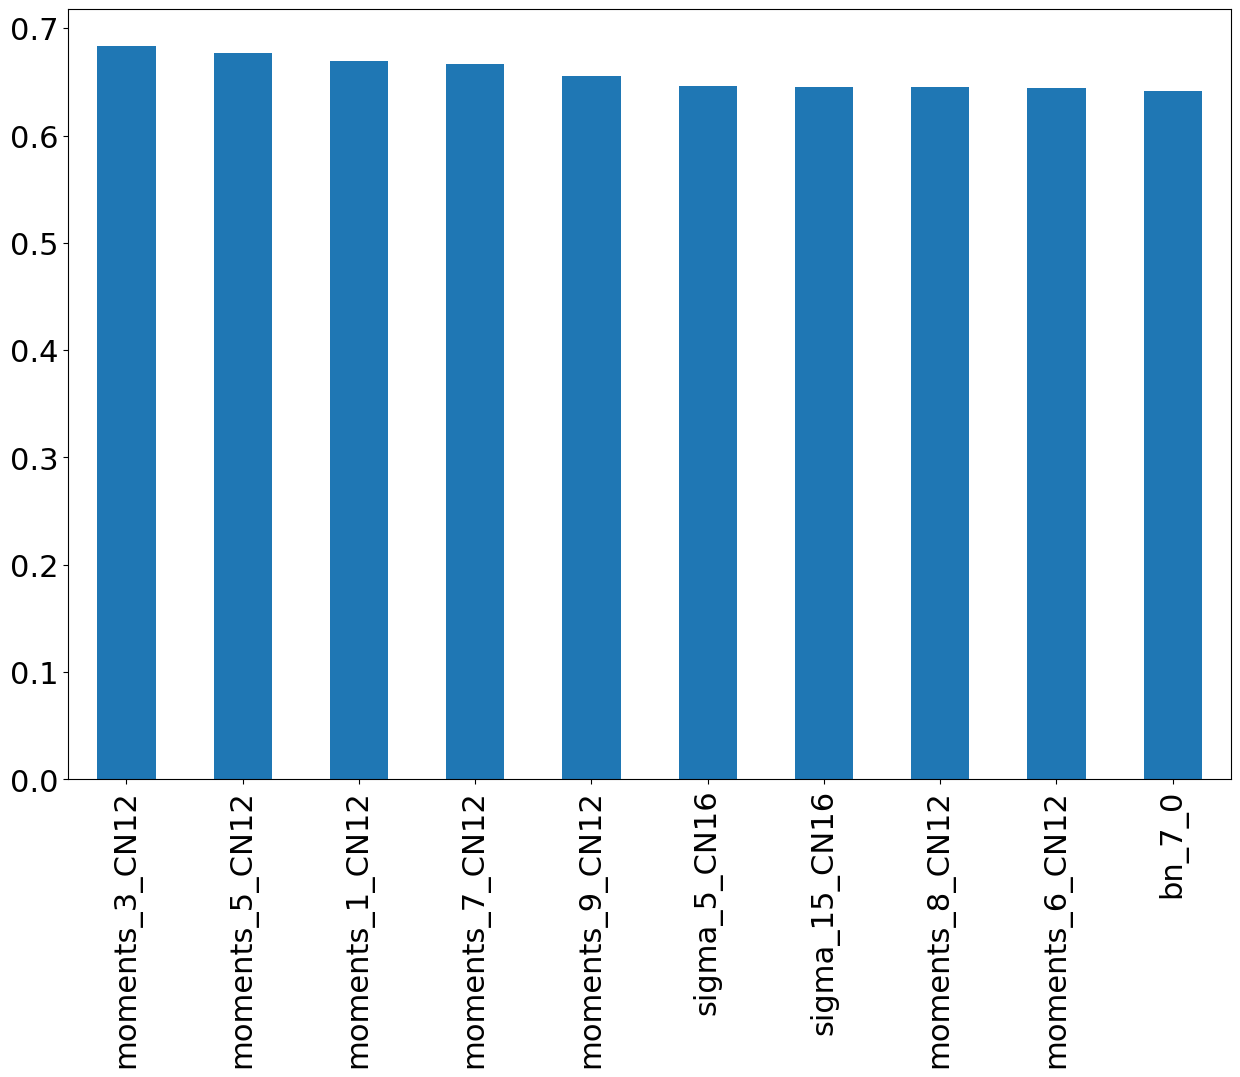

In [66]:
TargetCorrelations['projections'][:10].plot(kind='bar')

<AxesSubplot:>

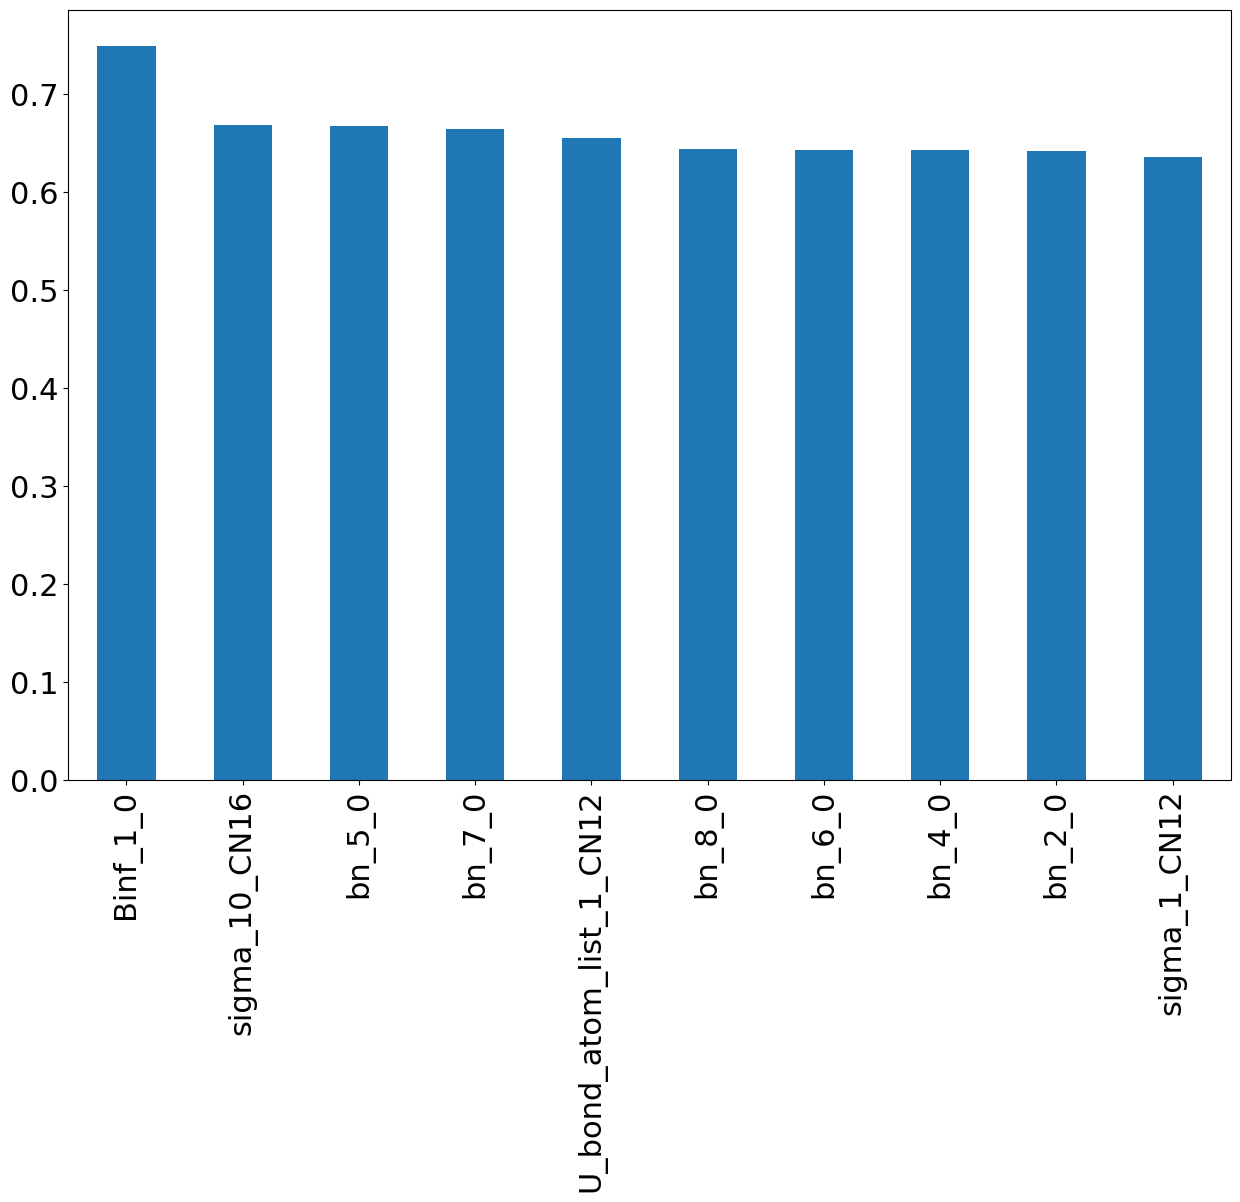

In [67]:
TargetCorrelations['projections_os'][:10].plot(kind='bar')

<AxesSubplot:xlabel='bn_7_0', ylabel='bn_8_0'>

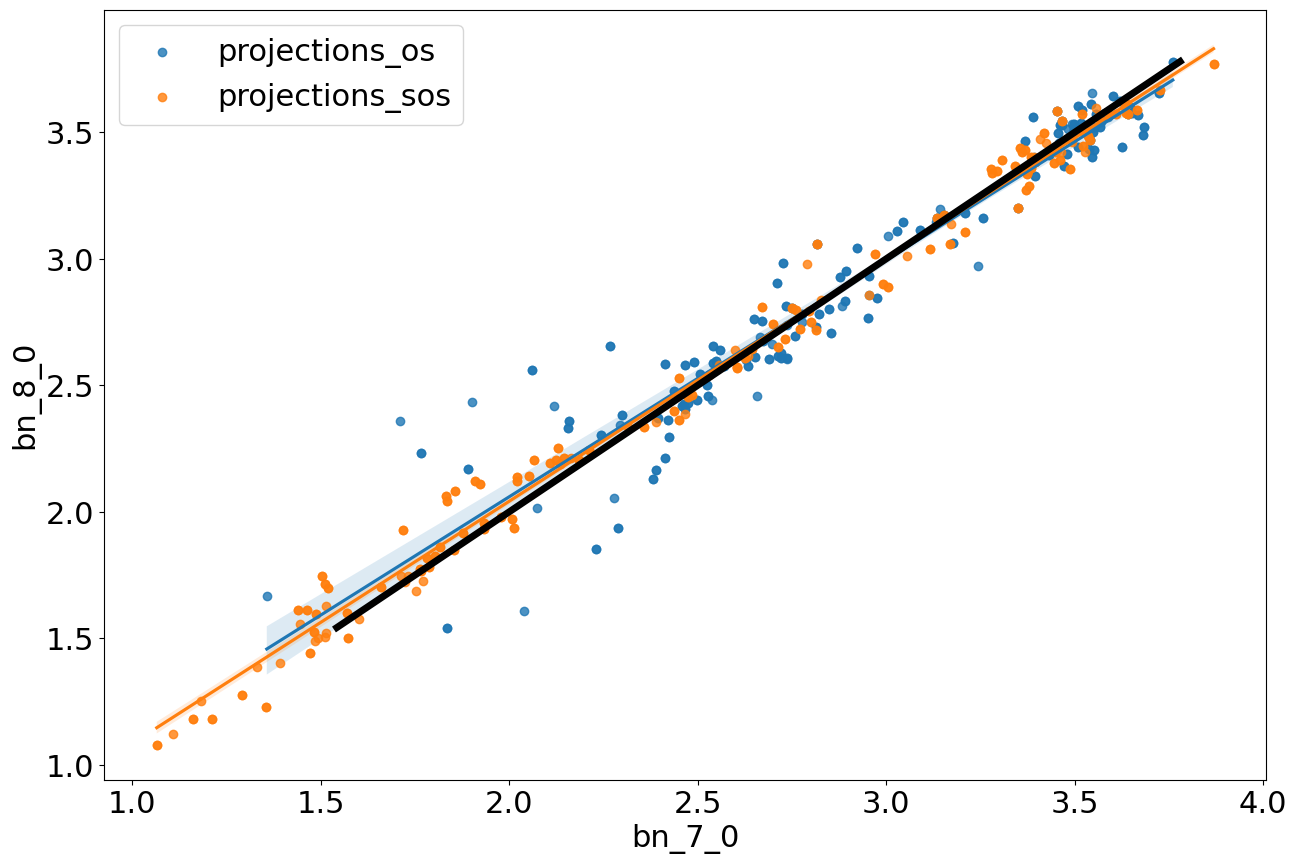

In [68]:
ax = sns.regplot(data = resultscnav['projections_os'],x='bn_7_0', y='bn_8_0' , label='projections_os')
ax = sns.regplot(data = resultscnav['projections_sos'],x='bn_7_0', y='bn_8_0' , label='projections_sos')
sns.lineplot(data = resultscnav['projections_os'],x='bn_8_0', y='bn_8_0' , ax=ax, linewidth=5, color= 'k')

<AxesSubplot:xlabel='bn_8_0', ylabel='bn_8_CN12'>

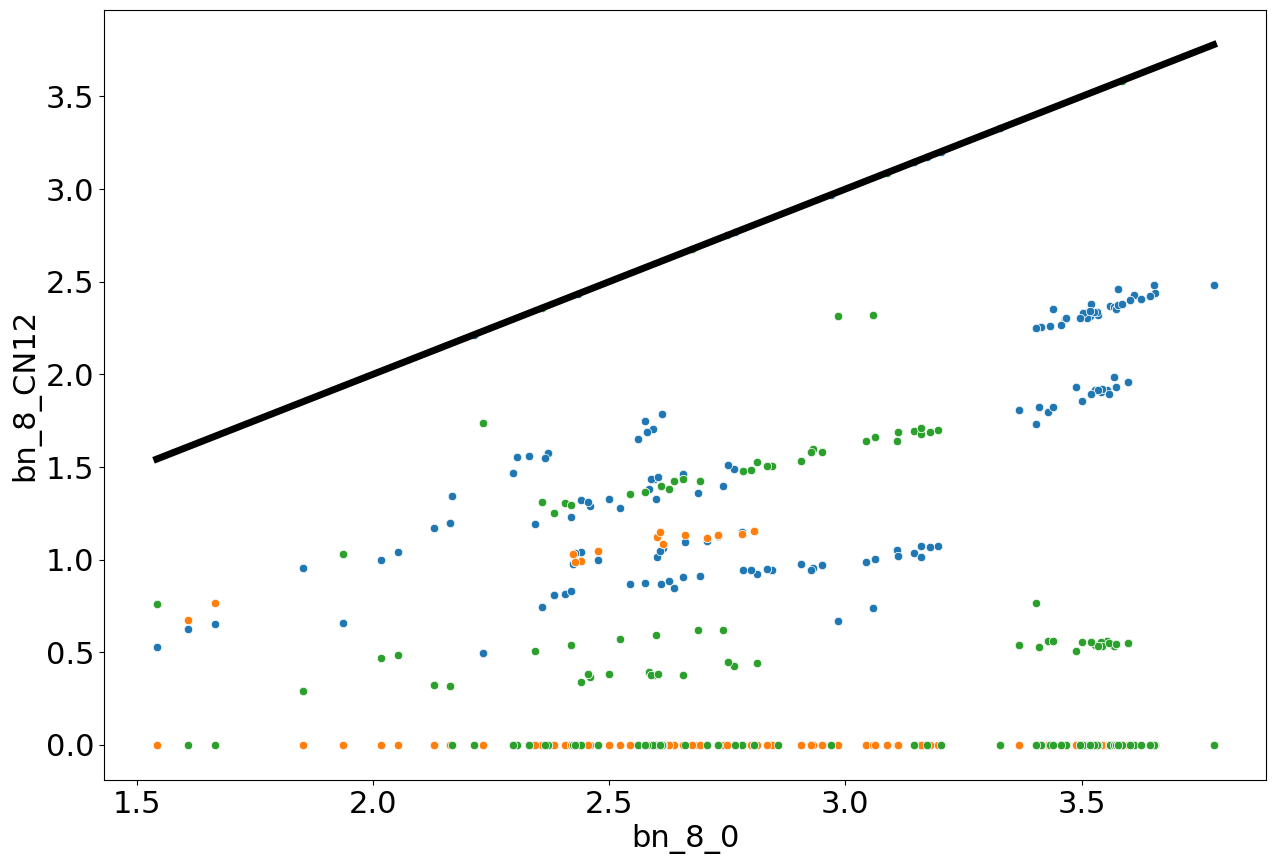

In [69]:
ax = sns.scatterplot(data = resultscnav['projections_os'],x='bn_8_0', y='bn_8_CN12' )
ax = sns.scatterplot(data = resultscnav['projections_os'],x='bn_8_0', y='bn_8_CN13', ax=ax )
ax = sns.scatterplot(data = resultscnav['projections_os'],x='bn_8_0', y='bn_8_CN14', ax=ax )
sns.lineplot(data = resultscnav['projections_os'],x='bn_8_0', y='bn_8_0' , ax=ax, linewidth=5, color= 'k')

<AxesSubplot:xlabel='$\\langle B_{\\infty} \\rangle _{CN16}$', ylabel='$\\Delta E_f$'>

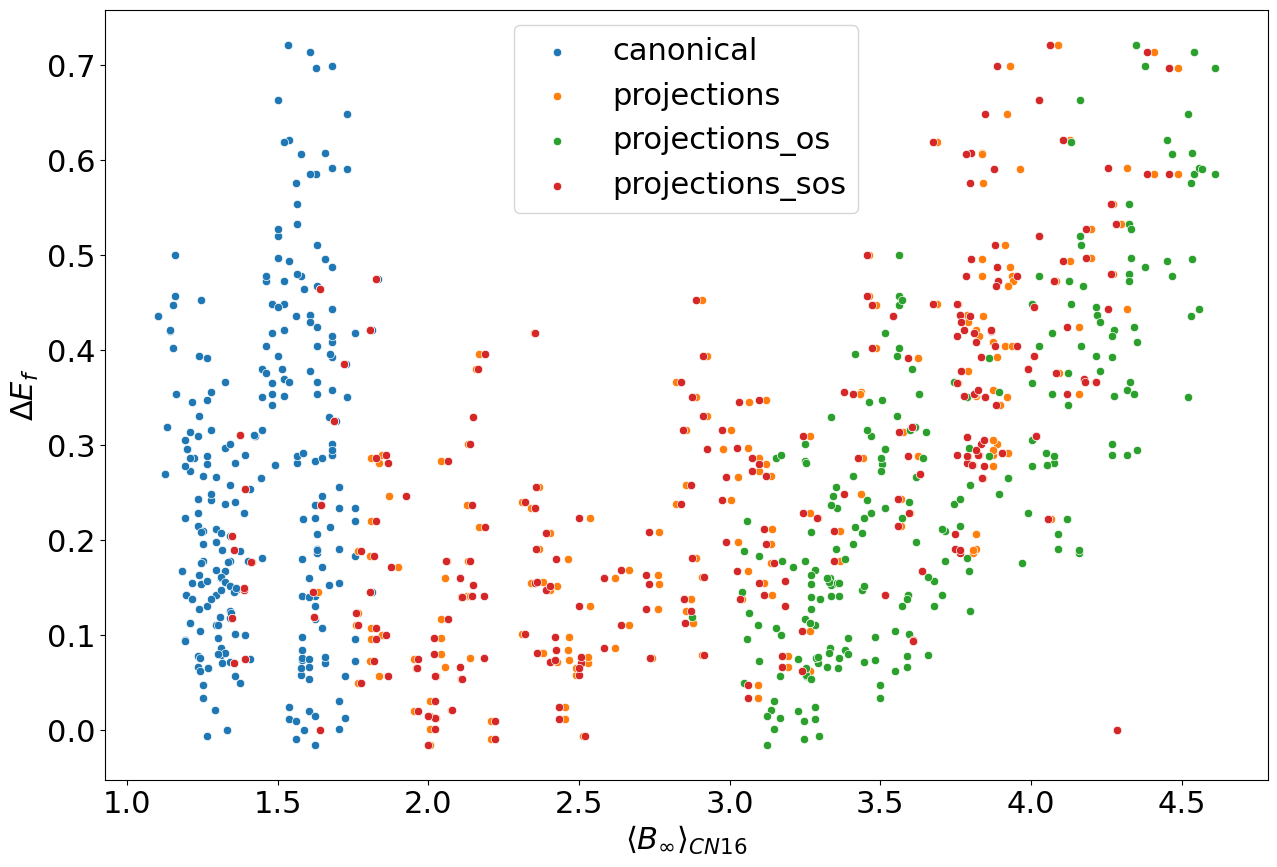

In [70]:
target_correlation_scatters('Binf_1_0', r'$\langle B_{\infty} \rangle _{CN16}$')

<AxesSubplot:xlabel='$\\langle a_{\\infty} \\rangle _{CN12}$', ylabel='$\\Delta E_f$'>

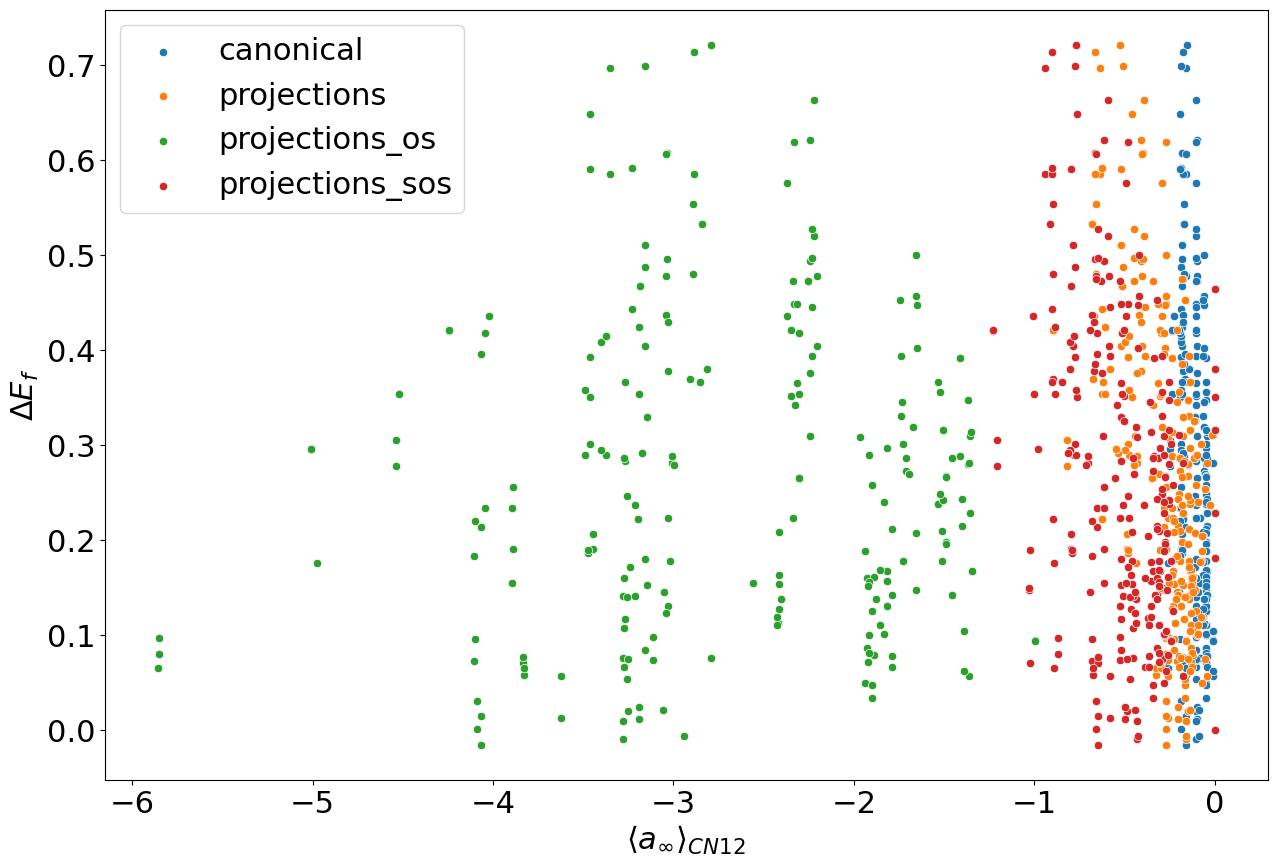

In [71]:
target_correlation_scatters('Ainf_1_CN12', r'$\langle a_{\infty} \rangle _{CN12}$')

<AxesSubplot:xlabel='$\\langle b_{8} \\rangle $', ylabel='$\\Delta E_f$'>

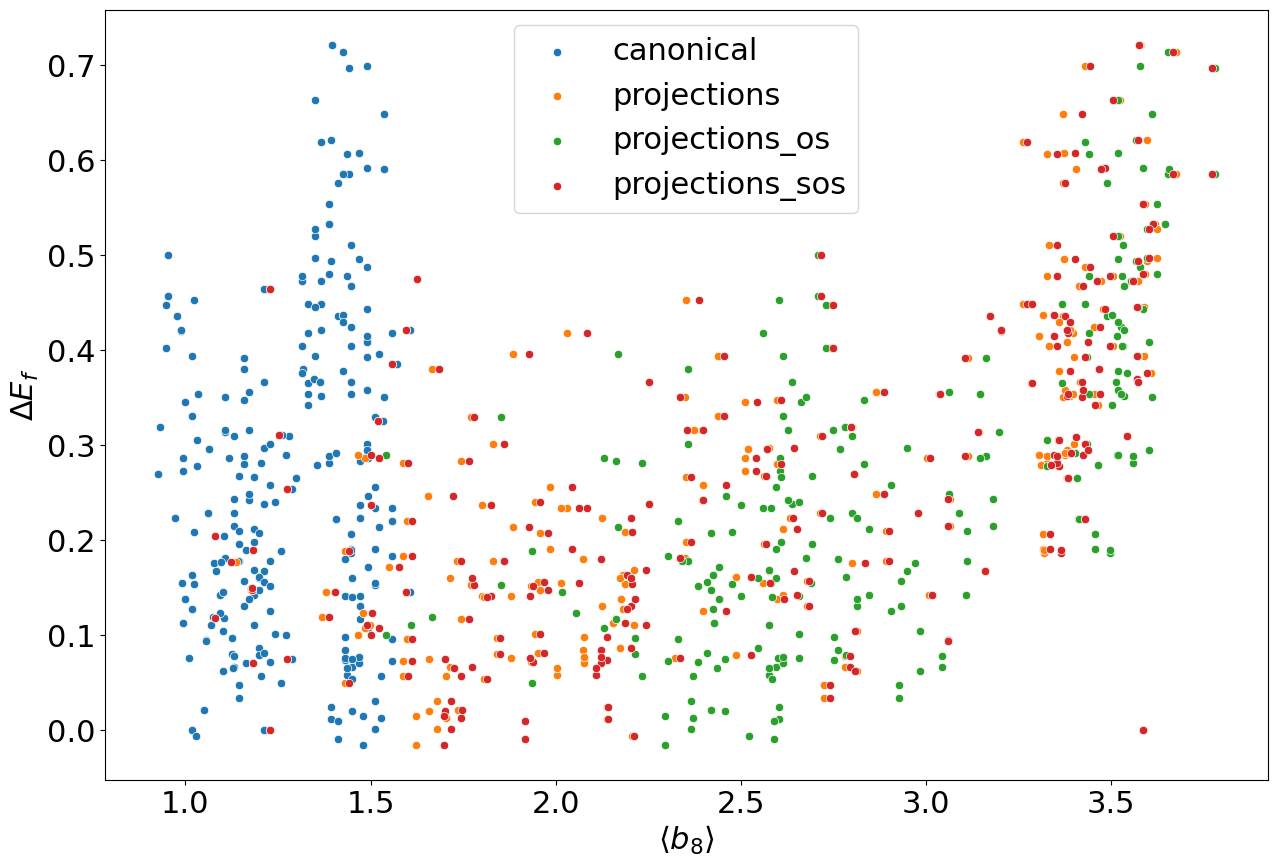

In [72]:
target_correlation_scatters('bn_8_0', r'$\langle b_{8} \rangle $')

# save curated CNAV BOPS

In [73]:
resultspickle

{'canonical': 'Fe-Mo/Descriptors/parallel_FeMo_initial_canonical_table_WUBIND_16.pkl',
 'projections': 'Fe-Mo/Descriptors/parallel_FeMo_initial_projections_table_WUBIND_16.pkl',
 'projections_os': 'Fe-Mo/Descriptors/parallel_FeMo_initial_projections_os_table_WUBIND_16.pkl',
 'projections_sos': 'Fe-Mo/Descriptors/parallel_FeMo_initial_projections_sos_table_WUBIND_16.pkl'}

In [74]:
curatedfiles = {model: file.replace('parallel', 'curated') for model,file in resultspickle.items()}

In [75]:
[resultscnav[model].to_pickle(file) for model, file in curatedfiles.items()]

[None, None, None, None]

# save features correlated to target for ML 

In [76]:
preselection = {}

In [77]:
for model in models:
    selection = TargetCorrelations[model] > 0.2
    preselection[model] = resultscnav[model].loc[:,selection]

In [78]:
preselection['canonical']

,U_bind,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN14,moments_1_CN12,moments_1_CN14,moments_1_CN15,moments_1_CN16,moments_2_CN14,moments_2_CN15,...,Ainf_1_CN12,Ainf_1_CN16,Binf_1_0,Binf_1_CN12,Binf_1_CN14,Binf_1_CN16,sf_0,sf_CN14,sf_CN15,sf_CN16
Fe_pv8Mo_sv22.sigma-BBABB.FM,-100.702297,-7.906327,-1.428383,-6.005237,0.433709,0.617709,0.123145,0.000000,-0.157690,-0.034385,...,-0.044826,0.000000,1.236738,0.411404,0.660966,0.000000,1.224171,1.187302,1.155462,0.000000
Fe_pv10Mo_sv20.sigma-ABBAB.FM,-78.594335,-7.771059,-1.424594,-5.906606,0.443751,0.632013,0.125997,0.000000,-0.163199,-0.035586,...,-0.045342,0.000000,1.250974,0.416140,0.668575,0.000000,1.224174,1.187308,1.155463,0.000000
Fe_pv4Mo_sv20.C36-ABBBB.FM,-94.449166,-8.534487,-7.595698,0.000000,1.079142,0.000000,0.000000,0.223928,0.000000,0.000000,...,-0.171309,-0.076269,1.563349,1.061812,0.000000,0.501537,1.081732,0.000000,0.000000,0.901327
Fe_pv5Mo_sv24.chi-AABB.FM,-116.205661,-8.244366,-6.070495,0.000000,0.589668,0.000000,0.000000,0.138224,0.000000,0.000000,...,-0.057968,-0.028074,1.160480,0.522949,0.000000,0.186186,1.251703,0.000000,0.000000,1.006205
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,-121.105805,-8.136275,-2.533063,-0.844603,0.765044,0.243853,0.097487,0.112354,-0.055466,-0.026452,...,-0.081697,-0.023692,1.217475,0.665006,0.256809,0.170809,1.192249,1.139857,0.956735,0.947607
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,-40.035290,-8.020136,-2.520056,-0.663807,0.918735,0.129279,0.091524,0.125524,-0.028171,-0.019380,...,-0.100951,-0.027733,1.482176,0.814720,0.220371,0.222761,1.071111,0.902499,0.748344,1.001884
Fe_pv8Mo_sv22.sigma-BBABB.NM,-100.702297,-7.906327,-1.428383,-6.005237,0.433709,0.617709,0.123145,0.000000,-0.157690,-0.034385,...,-0.044826,0.000000,1.236738,0.411404,0.660966,0.000000,1.224171,1.187302,1.155462,0.000000
Fe_pv1Mo_sv3.L12-AB3.FM,-12.617373,-6.832601,-6.832601,0.000000,1.063750,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.248815,0.000000,1.191642,1.191642,0.000000,0.000000,1.140024,0.000000,0.000000,0.000000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,-94.569986,-7.892530,-5.305761,-2.136368,0.433709,0.617709,0.123145,0.000000,-0.157690,-0.034385,...,-0.044826,0.000000,1.236738,0.411404,0.660966,0.000000,1.224171,1.187302,1.155462,0.000000


In [79]:
preselection['projections']

,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN14,moments_1_0,moments_1_CN12,moments_1_CN14,moments_1_CN15,moments_1_CN16,moments_2_0,moments_2_CN12,...,Ainf_1_CN12,Ainf_1_CN14,Ainf_1_CN16,Binf_1_0,Binf_1_CN12,Binf_1_CN14,Binf_1_CN16,sf_0,sf_CN14,sf_CN15
Fe_pv8Mo_sv22.sigma-BBABB.FM,-20.193048,-4.189695,-14.477331,7.855417,3.309780,3.449699,1.095939,0.000000,-8.966884,-3.932807,...,-0.205189,-0.348257,0.000000,3.569220,1.203140,1.882024,0.000000,1.110262,0.973712,1.236605
Fe_pv10Mo_sv20.sigma-ABBAB.FM,-18.033358,-1.665060,-14.938210,6.499347,1.097785,4.431293,0.970268,0.000000,-5.883703,-0.982669,...,-0.164926,-0.249126,0.000000,3.094141,1.018776,1.661629,0.000000,1.138826,1.301849,1.229805
Fe_pv4Mo_sv20.C36-ABBBB.FM,-23.447157,-20.951618,0.000000,9.818478,8.167350,0.000000,0.000000,1.651128,-11.898533,-9.559500,...,-0.658114,0.000000,-0.274842,4.272503,2.911853,0.000000,1.360649,1.080315,0.000000,0.000000
Fe_pv5Mo_sv24.chi-AABB.FM,-22.632131,-16.545654,0.000000,8.964497,4.445131,0.000000,0.000000,0.449140,-9.319933,-3.856357,...,-0.272366,0.000000,-0.119755,3.461279,1.492412,0.000000,0.544116,1.171632,0.000000,0.000000
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,-19.022689,-4.616740,-2.488935,6.923300,3.402464,1.734418,0.829175,0.957242,-6.102563,-3.249339,...,-0.254974,-0.113527,-0.078569,3.112177,1.637228,0.683398,0.459315,1.132588,1.254586,1.111686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,-20.879702,-6.549225,-1.351574,8.338945,5.761864,0.378577,1.021429,1.177075,-8.948138,-6.106496,...,-0.343769,-0.106222,-0.099221,3.896114,2.115588,0.594377,0.594075,1.052054,0.558826,0.962144
Fe_pv8Mo_sv22.sigma-BBABB.NM,-20.193048,-4.189695,-14.477331,7.855417,3.309780,3.449699,1.095939,0.000000,-8.966884,-3.932807,...,-0.205189,-0.348257,0.000000,3.569220,1.203140,1.882024,0.000000,1.110262,0.973712,1.236605
Fe_pv1Mo_sv3.L12-AB3.FM,-18.610242,-18.610242,0.000000,7.169932,7.169932,0.000000,0.000000,0.000000,-6.002303,-6.002303,...,-0.816063,0.000000,0.000000,3.874406,3.874406,0.000000,0.000000,1.032255,0.000000,0.000000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,-20.025057,-13.909531,-4.581247,7.618091,3.248811,3.267776,1.101504,0.000000,-7.653753,-3.113689,...,-0.173369,-0.303924,0.000000,3.266080,1.127205,1.713022,0.000000,1.139746,1.020259,1.187545


In [80]:
preselection['projections_os']

,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN14,moments_1_0,moments_1_CN12,moments_1_CN14,moments_1_CN16,moments_2_0,moments_2_CN12,moments_2_CN14,...,Ainf_1_0,Ainf_1_CN14,Ainf_1_CN16,Binf_1_0,Binf_1_CN12,Binf_1_CN14,Binf_1_CN16,sf_CN12,sf_CN14,sf_CN15
Fe_pv8Mo_sv22.sigma-BBABB.FM,-19.530265,-4.231208,-13.729532,29.986160,7.050613,20.343280,0.000000,-224.387200,-51.202267,-155.240533,...,-4.588208,-2.624485,0.000000,3.764350,1.258465,2.014324,0.000000,1.186340,0.889566,1.143677
Fe_pv10Mo_sv20.sigma-ABBAB.FM,-16.868948,-0.911223,-14.461947,31.357127,18.473913,10.416613,0.000000,-234.466667,-146.543067,-71.644000,...,-4.662312,-2.211893,0.000000,3.496914,1.233802,1.810703,0.000000,0.731383,1.078793,1.025442
Fe_pv4Mo_sv20.C36-ABBBB.FM,-23.221296,-20.815692,0.000000,27.858617,15.649017,0.000000,12.209600,-209.105333,-117.974333,0.000000,...,-4.548612,0.000000,-1.657400,4.326196,2.918388,0.000000,1.407807,1.155487,0.000000,0.000000
Fe_pv5Mo_sv24.chi-AABB.FM,-22.341153,-16.387714,0.000000,27.239741,9.088924,0.000000,9.436790,-200.631897,-65.132690,0.000000,...,-4.302478,0.000000,-0.979924,3.561968,1.490963,0.000000,0.632890,1.224200,0.000000,0.000000
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,-17.966306,-3.871873,-2.569110,29.722943,20.696728,4.275358,2.651208,-220.876298,-162.063943,-28.348113,...,-4.555742,-0.915569,-0.629319,3.362689,1.817649,0.711491,0.482319,0.965685,1.027020,0.974523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,-20.456827,-6.467102,-1.206937,29.001277,14.951354,8.398338,2.903615,-217.089923,-115.391769,-65.032000,...,-4.517334,-0.887523,-0.647699,4.122159,2.226251,0.664690,0.618189,1.116006,0.550890,0.962144
Fe_pv8Mo_sv22.sigma-BBABB.NM,-19.530265,-4.231208,-13.729532,29.986160,7.050613,20.343280,0.000000,-224.387200,-51.202267,-155.240533,...,-4.588208,-2.624485,0.000000,3.764350,1.258465,2.014324,0.000000,1.186340,0.889566,1.143677
Fe_pv1Mo_sv3.L12-AB3.FM,-18.224074,-18.224074,0.000000,28.618900,28.618900,0.000000,0.000000,-210.312000,-210.312000,0.000000,...,-4.534946,0.000000,0.000000,4.003281,4.003281,0.000000,0.000000,0.934608,0.000000,0.000000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,-19.379986,-13.592292,-4.179866,29.748847,6.989647,20.161360,0.000000,-221.143667,-49.810600,-153.811200,...,-4.471563,-2.583679,0.000000,3.468307,1.159246,1.882278,0.000000,1.151679,0.920171,1.068554


In [81]:
for model in models:
    preselected_location = os.path.join(descriptorlocation, f'preselected_cnav_{model}_BOPds.pkl')
    preselection[model].to_pickle(preselected_location)

# save features with low order of moments

In [82]:
smallorder = {}

In [83]:
for model in models:
    smallorder[model]=resultscnav[model].filter(regex='an_[0-6]_|bn_[0-6]|^moments_[0-6]|normed|sigma_[0-6]_')
    smallorder_location = os.path.join(descriptorlocation, f'smallorder_cnav_{model}_BOP.pkl')
    smallorder[model].to_pickle(smallorder_location)

In [84]:
doprints = [print(pre) for pre in preselected if 'CN12' in pre]

NameError: name 'preselected' is not defined

In [ ]:
BS